In [1]:
!pip install pandas

zsh:1: /Users/shimizutoorushin/Desktop/大学\M-h\M-,-義/M1\M-f|(業program/M1_Class/.venv/bin/pip: bad interpreter: /Users/shimizutoorushin/Desktop/M1_Class_program/M1_Class/.venv/bin/python: no such file or directory
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-pa

### 大域的な解釈可能性

モデルに依存しない解釈

In [2]:
# データの読み込み

import pandas as pd

df = pd.read_csv('students_performance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# 80点以上でA/60-80でB/40-60でC/40点未満でF

def score_to_grade(score):
    if score >= 80:
        return 'A'
    if score >= 60:
        return 'B'
    if score >= 40:
        return 'C'
    return 'F'

df['math grade'] = df['math score'].apply(score_to_grade)
df['reading grade'] = df['reading score'].apply(score_to_grade)
df['writing grade'] = df['writing score'].apply(score_to_grade)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math grade,reading grade,writing grade
0,female,group B,bachelor's degree,standard,none,72,72,74,B,B,B
1,female,group C,some college,standard,completed,69,90,88,B,A,A
2,female,group B,master's degree,standard,none,90,95,93,A,A,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,C,C,C
4,male,group C,some college,standard,none,76,78,75,B,B,B


#### 探索的データ解析 (EDA)

In [4]:
# データにおける男女の割合

df['gender'].value_counts() / len(df) * 100

gender
female    51.8
male      48.2
Name: count, dtype: float64

(0.0, 25.0)

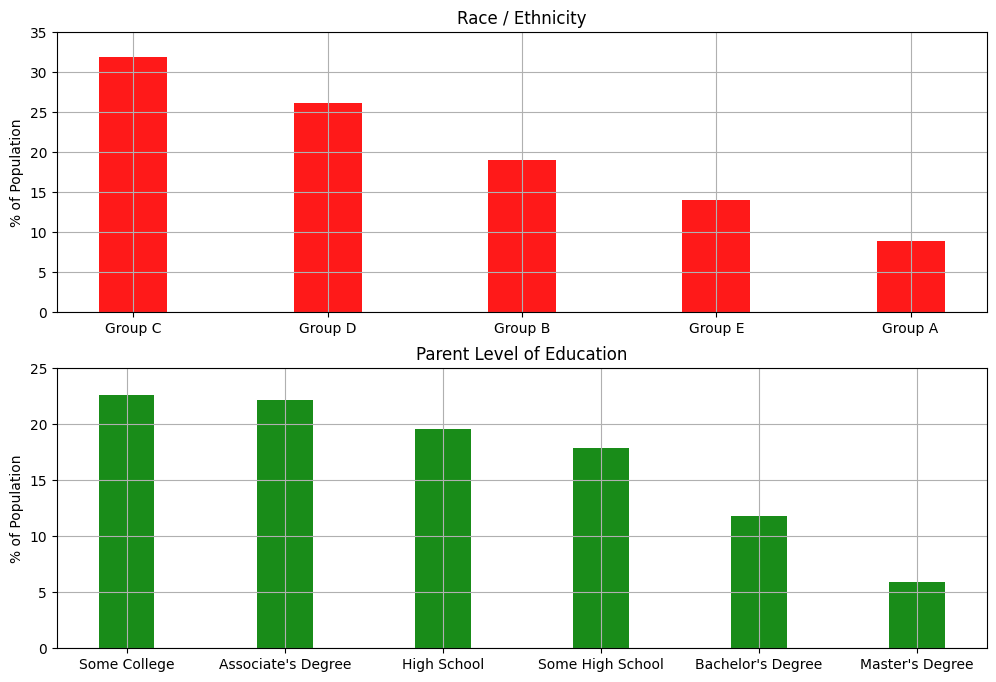

In [5]:
# 特徴量の比率を可視化

import numpy as np
import matplotlib.pyplot as plt

def plot_vc_bar_charts(df, col, ax, color='b'):
    df_vc = df[col].value_counts() / len(df) * 100
    df_vc = df_vc.reset_index()
    df_vc = df_vc.rename(columns={'index': col, col: 'pc'})

    bar_width = 0.35
    opacity = 0.9
    labels = df_vc['pc'].values
    capitalized_labels = []
    for label in labels:
        words = label.split(' ')
        capitalized_label = ' '.join([w.capitalize() for w in words])
        capitalized_labels.append(capitalized_label)
    sizes = df_vc['count'].values
    index = np.arange(len(sizes))

    ax.bar(index, sizes, bar_width, alpha=opacity, label=labels, color=color)
    ax.set_xticks(index)
    ax.set_xticklabels(capitalized_labels)
    ax.grid(True)

# 人種と両親の学歴の分布を可視化

f, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_vc_bar_charts(df, 'race/ethnicity', ax=ax[0], color='r')
plot_vc_bar_charts(df, 'parental level of education', ax=ax[1], color='g')
ax[0].set_title('Race / Ethnicity')
ax[1].set_title('Parent Level of Education')
ax[0].set_ylabel('% of Population')
ax[1].set_ylabel('% of Population')
ax[0].set_ylim([0, 35])
ax[1].set_ylim([0, 25])

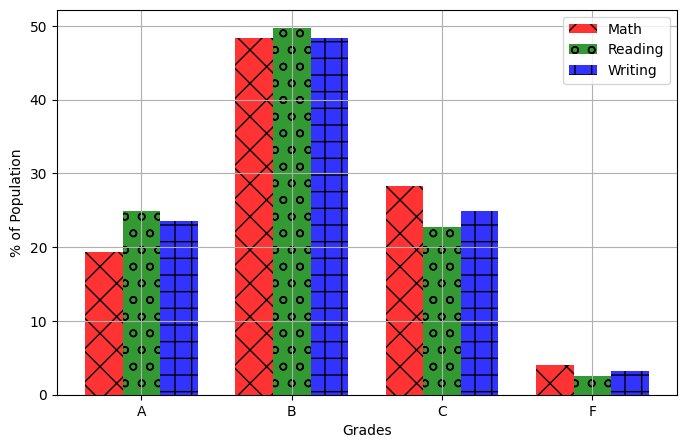

In [6]:
# 3教科の評価の割合

def get_stats(df, grade_col):
    df_grade = df.groupby([grade_col]).agg({'lunch': 'count'}).reset_index()
    df_grade = df_grade.rename(columns={'lunch': 'count'})
    df_grade['pc'] = df_grade['count'] / len(df) * 100

    df_gender = df.groupby(['gender', grade_col]).agg({'lunch': 'count'}).reset_index()
    df_gender = df_gender.rename(columns={'lunch': 'count'})
    df_gender['pc'] = df_gender['count'] / len(df) * 100

    df_race = df.groupby(['race/ethnicity', grade_col]).agg({'lunch': 'count'}).reset_index()
    df_race = df_race.rename(columns={'lunch': 'count'})
    df_race['pc'] = df_race['count'] / len(df) * 100

    df_parent = df.groupby(['parental level of education', grade_col]).agg({'lunch': 'count'}).reset_index()
    df_parent = df_parent.rename(columns={'lunch': 'count'})
    df_parent['pc'] = df_parent['count'] / len(df) * 100

    df_lunch = df.groupby(['lunch', grade_col]).agg({'gender': 'count'}).reset_index()
    df_lunch = df_lunch.rename(columns={'gender': 'count'})
    df_lunch['pc'] = df_lunch['count'] / len(df) * 100

    df_test_prep = df.groupby(['test preparation course', grade_col]).agg({'gender': 'count'}).reset_index()
    df_test_prep = df_test_prep.rename(columns={'gender': 'count'})
    df_test_prep['pc'] = df_lunch['count'] / len(df) * 100

    return df_grade, df_gender, df_race, df_parent, df_lunch, df_test_prep

df_grade_math, df_gender_math, df_race_math, df_parent_math, df_lunch_math, df_test_prep_math = get_stats(df, 'math grade')
df_grade_reading, df_gender_reading, df_race_reading, df_parent_reading, df_lunch_reading, df_test_prep_reading = get_stats(df, 'reading grade')
df_grade_writing, df_gender_writing, df_race_writing, df_parent_writing, df_lunch_writing, df_test_prep_writing = get_stats(df, 'writing grade')

fig, ax = plt.subplots(figsize=(8, 5))
grades = ['A', 'B', 'C', 'F']
index = np.arange(len(grades))
bar_width = 0.25

opacity = 0.8
error_config = {'ecolor': '0.3'}

ax.bar(index, df_grade_math['pc'], bar_width, alpha=opacity, color='r', label='Math', hatch='x')
ax.bar(index + bar_width, df_grade_reading['pc'], bar_width, alpha=opacity, color='g', label='Reading', hatch='o')
ax.bar(index + bar_width * 2, df_grade_writing['pc'], bar_width, alpha=opacity, color='b', label='Writing', hatch='+')

ax.set_xlabel('Grades')
ax.set_ylabel('% of Population')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(grades)
ax.legend()
ax.grid(True)

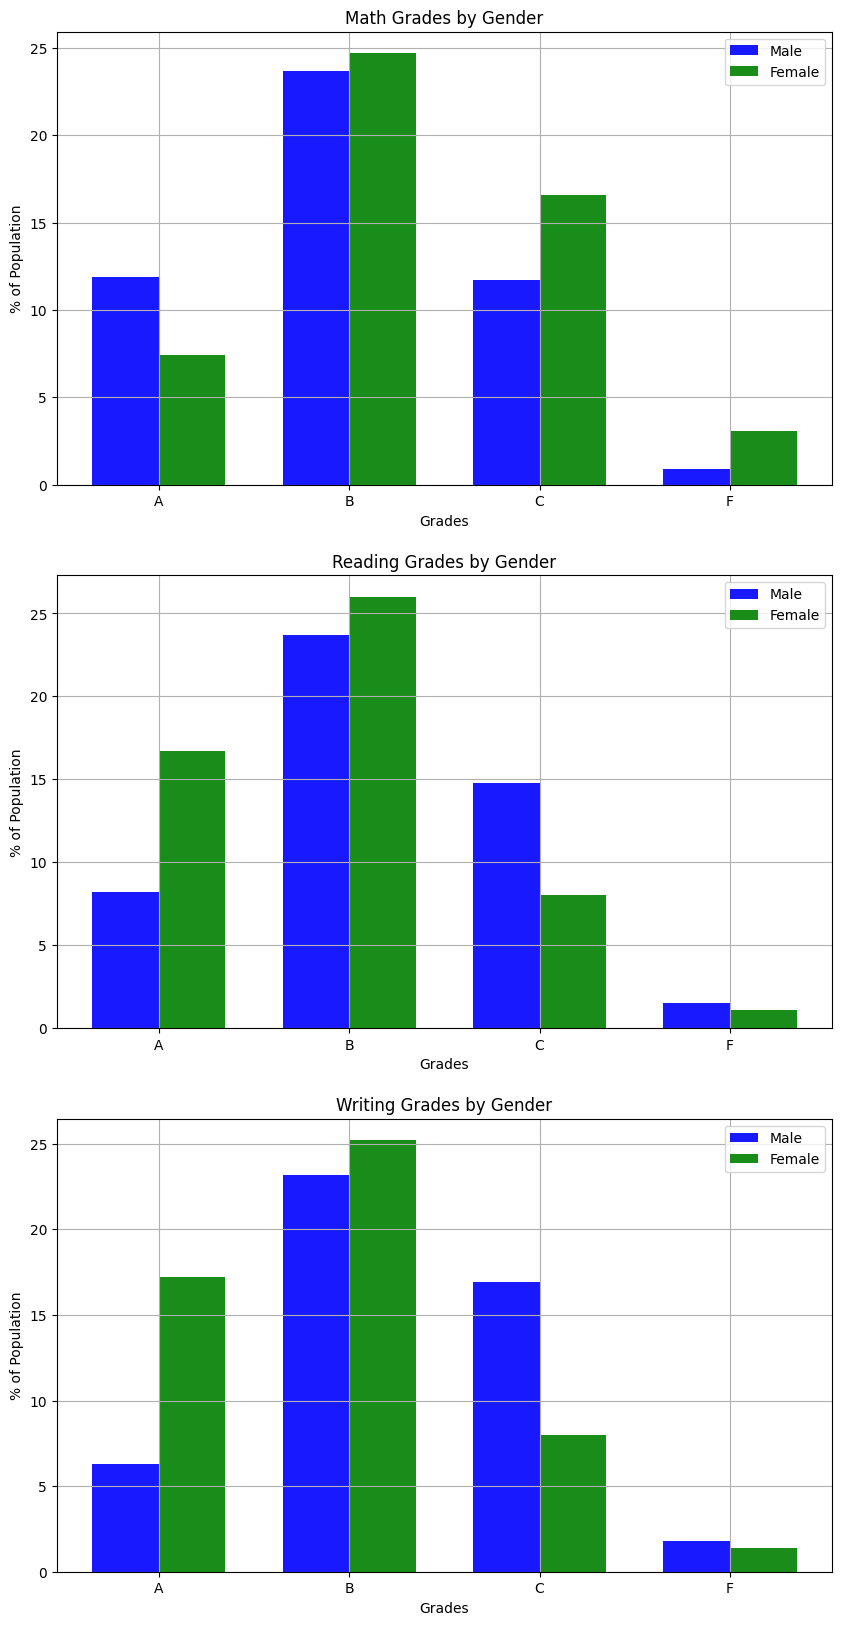

In [7]:
# 性別と各科目の評価の関係

fig, ax = plt.subplots(3, 1, figsize=(10, 20))

grades = ['A', 'B', 'C', 'F']
index = np.arange(len(grades))
bar_width = 0.35

opacity = 0.9
error_config = {'ecolor': '0.3'}

ax[0].bar(index, df_gender_math[df_gender_math['gender'] == 'male']['pc'], bar_width, alpha=opacity, color='b', label='Male')
ax[0].bar(index + bar_width, df_gender_math[df_gender_math['gender'] == 'female']['pc'], bar_width, alpha=opacity, color='g', label='Female')

ax[0].set_xlabel('Grades')
ax[0].set_ylabel('% of Population')
ax[0].set_title('Math Grades by Gender')
ax[0].set_xticks(index + bar_width / 2)
ax[0].set_xticklabels(grades)
ax[0].legend()
ax[0].grid(True)

ax[1].bar(index, df_gender_reading[df_gender_reading['gender'] == 'male']['pc'], bar_width, alpha=opacity, color='b', label='Male')
ax[1].bar(index + bar_width, df_gender_reading[df_gender_reading['gender'] == 'female']['pc'], bar_width, alpha=opacity, color='g', label='Female')

ax[1].set_xlabel('Grades')
ax[1].set_ylabel('% of Population')
ax[1].set_title('Reading Grades by Gender')
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(grades)
ax[1].legend()
ax[1].grid(True)

ax[2].bar(index, df_gender_writing[df_gender_writing['gender'] == 'male']['pc'], bar_width, alpha=opacity, color='b', label='Male')
ax[2].bar(index + bar_width, df_gender_writing[df_gender_writing['gender'] == 'female']['pc'], bar_width, alpha=opacity, color='g', label='Female')

ax[2].set_xlabel('Grades')
ax[2].set_ylabel('% of Population')
ax[2].set_title('Writing Grades by Gender')
ax[2].set_xticks(index + bar_width / 2)
ax[2].set_xticklabels(grades)
ax[2].legend()
ax[2].grid(True)

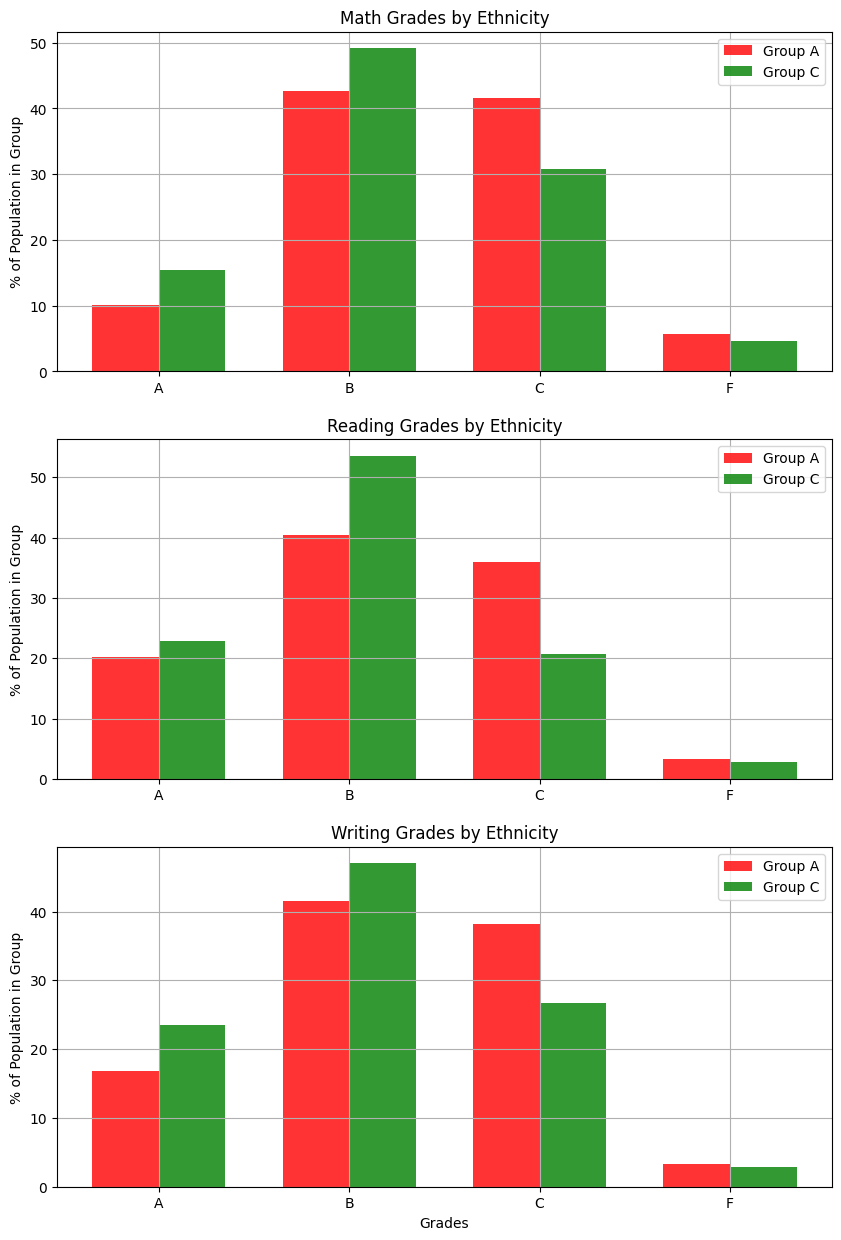

In [8]:
# 人種A/Cに属する生徒における各科目の評価

fig, ax = plt.subplots(3, 1, figsize=(10, 15))

grades = ['A', 'B', 'C', 'F']
index = np.arange(len(grades))
bar_width = 0.35

opacity = 0.8
error_config = {'ecolor': '0.3'}

math_a_sum = df_race_math[df_race_math['race/ethnicity'] == 'group A']['pc'].sum()
math_c_sum = df_race_math[df_race_math['race/ethnicity'] == 'group C']['pc'].sum()
ax[0].bar(index, df_race_math[df_race_math['race/ethnicity'] == 'group A']['pc'] / math_a_sum * 100, bar_width, alpha=opacity, color='r', label='Group A')
ax[0].bar(index + bar_width, df_race_math[df_race_math['race/ethnicity'] == 'group C']['pc'] / math_c_sum * 100, bar_width, alpha=opacity, color='g', label='Group C')

ax[0].set_xlabel('')
ax[0].set_ylabel('% of Population in Group')
ax[0].set_title('Math Grades by Ethnicity')
ax[0].set_xticks(index + bar_width / 2)
ax[0].set_xticklabels(grades)
ax[0].legend()
ax[0].grid(True)

read_a_sum = df_race_reading[df_race_reading['race/ethnicity'] == 'group A']['pc'].sum()
read_c_sum = df_race_reading[df_race_reading['race/ethnicity'] == 'group C']['pc'].sum()
ax[1].bar(index, df_race_reading[df_race_reading['race/ethnicity'] == 'group A']['pc'] / read_a_sum * 100, bar_width, alpha=opacity, color='r', label='Group A')
ax[1].bar(index + bar_width, df_race_reading[df_race_reading['race/ethnicity'] == 'group C']['pc'] / read_c_sum * 100, bar_width, alpha=opacity, color='g', label='Group C')

ax[1].set_xlabel('')
ax[1].set_ylabel('% of Population in Group')
ax[1].set_title('Reading Grades by Ethnicity')
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(grades)
ax[1].legend()
ax[1].grid(True)

write_a_sum = df_race_writing[df_race_writing['race/ethnicity'] == 'group A']['pc'].sum()
write_c_sum = df_race_writing[df_race_writing['race/ethnicity'] == 'group C']['pc'].sum()
ax[2].bar(index, df_race_writing[df_race_writing['race/ethnicity'] == 'group A']['pc'] / write_a_sum * 100, bar_width, alpha=opacity, color='r', label='Group A')
ax[2].bar(index + bar_width, df_race_writing[df_race_writing['race/ethnicity'] == 'group C']['pc'] / write_c_sum * 100, bar_width, alpha=opacity, color='g', label='Group C')

ax[2].set_xlabel('Grades')
ax[2].set_ylabel('% of Population in Group')
ax[2].set_title('Writing Grades by Ethnicity')
ax[2].set_xticks(index + bar_width / 2)
ax[2].set_xticklabels(grades)
ax[2].legend()
ax[2].grid(True)

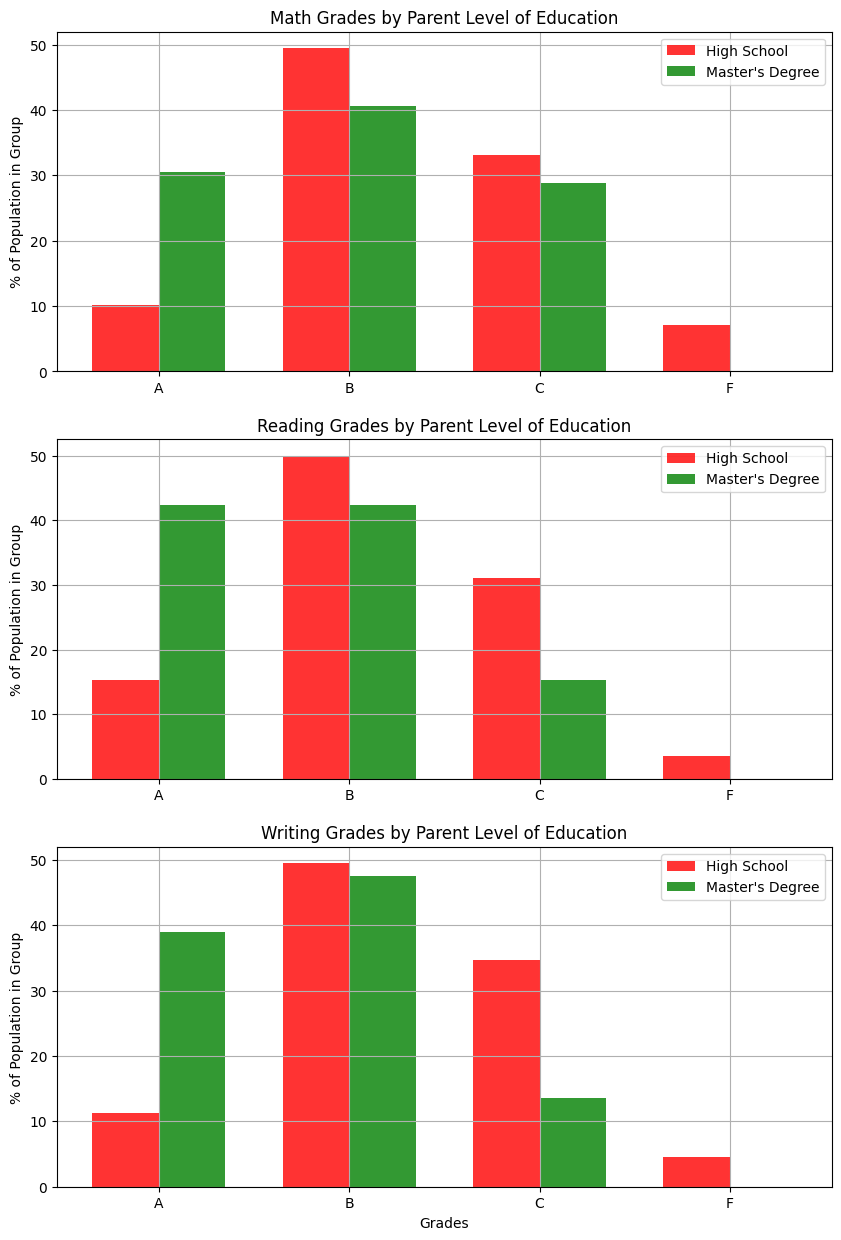

In [9]:
# 両親の学歴と生徒の学歴の関係

fig, ax = plt.subplots(3, 1, figsize=(10, 15))

grades = ['A', 'B', 'C', 'F']
index = np.arange(len(grades))
bar_width = 0.35

opacity = 0.8
error_config = {'ecolor': '0.3'}

math_a_sum = df_parent_math[df_parent_math['parental level of education'] == 'high school']['pc'].sum()
math_c_sum = df_parent_math[df_parent_math['parental level of education'] == 'master\'s degree']['pc'].sum()
math_ma_pc = np.array(df_parent_math[df_parent_math['parental level of education'] == 'master\'s degree']['pc'].values) / math_c_sum * 100
math_ma_pc = np.append(math_ma_pc, 0) # for grade f
ax[0].bar(index, df_parent_math[df_parent_math['parental level of education'] == 'high school']['pc'] / math_a_sum * 100, bar_width, alpha=opacity, color='r', label='High School')
ax[0].bar(index + bar_width, math_ma_pc, bar_width, alpha=opacity, color='g', label='Master\'s Degree')

ax[0].set_xlabel('')
ax[0].set_ylabel('% of Population in Group')
ax[0].set_title('Math Grades by Parent Level of Education')
ax[0].set_xticks(index + bar_width / 2)
ax[0].set_xticklabels(grades)
ax[0].legend()
ax[0].grid(True)

read_a_sum = df_parent_reading[df_parent_reading['parental level of education'] == 'high school']['pc'].sum()
read_c_sum = df_parent_reading[df_parent_reading['parental level of education'] == 'master\'s degree']['pc'].sum()
read_ma_pc = np.array(df_parent_reading[df_parent_reading['parental level of education'] == 'master\'s degree']['pc'].values) / read_c_sum * 100
read_ma_pc = np.append(read_ma_pc, 0) # for grade f
ax[1].bar(index, df_parent_reading[df_parent_reading['parental level of education'] == 'high school']['pc'] / read_a_sum * 100, bar_width, alpha=opacity, color='r', label='High School')
ax[1].bar(index + bar_width, read_ma_pc, bar_width, alpha=opacity, color='g', label='Master\'s Degree')

ax[1].set_xlabel('')
ax[1].set_ylabel('% of Population in Group')
ax[1].set_title('Reading Grades by Parent Level of Education')
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(grades)
ax[1].legend()
ax[1].grid(True)

write_a_sum = df_parent_writing[df_parent_writing['parental level of education'] == 'high school']['pc'].sum()
write_c_sum = df_parent_writing[df_parent_writing['parental level of education'] == 'master\'s degree']['pc'].sum()
write_ma_pc = np.array(df_parent_writing[df_parent_writing['parental level of education'] == 'master\'s degree']['pc'].values) / write_c_sum * 100
write_ma_pc = np.append(write_ma_pc, 0) # for grade f
ax[2].bar(index, df_parent_writing[df_parent_writing['parental level of education'] == 'high school']['pc'] / write_a_sum * 100, bar_width, alpha=opacity, color='r', label='High School')
ax[2].bar(index + bar_width, write_ma_pc, bar_width, alpha=opacity, color='g', label='Master\'s Degree')

ax[2].set_xlabel('Grades')
ax[2].set_ylabel('% of Population in Group')
ax[2].set_title('Writing Grades by Parent Level of Education')
ax[2].set_xticks(index + bar_width / 2)
ax[2].set_xticklabels(grades)
ax[2].legend()
ax[2].grid(True)

#### データの準備

In [10]:
# カテゴリカルデータを数値データに変換

from sklearn.preprocessing import LabelEncoder

ple = ['high school', 'some high school', 'some college', "bachelor's degree", "associate's degree", "master's degree"]
ple_map = {}
for idx, p in enumerate(ple):
    ple_map[p] = idx

gender_le = LabelEncoder()
race_le = LabelEncoder()
parent_le = LabelEncoder()
lunch_le = LabelEncoder()
test_prep_le = LabelEncoder()

gender_le.fit(df['gender'])
race_le.fit(df['race/ethnicity'])
parent_le.fit(df['parental level of education'])
lunch_le.fit(df['lunch'])
test_prep_le.fit(df['test preparation course'])

df['gender_le'] = gender_le.transform(df['gender'])
df['race_le'] = race_le.transform(df['race/ethnicity'])
df['parent_le'] = df['parental level of education'].apply(lambda x: ple_map[x])
df['lunch_le'] = lunch_le.transform(df['lunch'])
df['test_prep_le'] = test_prep_le.transform(df['test preparation course'])

math_grade_le = LabelEncoder()
reading_grade_le = LabelEncoder()
writing_grade_le = LabelEncoder()

math_grade_le.fit(df['math grade'])
reading_grade_le.fit(df['reading grade'])
writing_grade_le.fit(df['writing grade'])

df['math_grade_le'] = math_grade_le.transform(df['math grade'])
df['reading_grade_le'] = reading_grade_le.transform(df['reading grade'])
df['writing_grade_le'] = writing_grade_le.transform(df['writing grade'])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math grade,reading grade,writing grade,gender_le,race_le,parent_le,lunch_le,test_prep_le,math_grade_le,reading_grade_le,writing_grade_le
0,female,group B,bachelor's degree,standard,none,72,72,74,B,B,B,0,1,3,1,1,1,1,1
1,female,group C,some college,standard,completed,69,90,88,B,A,A,0,2,2,1,0,1,0,0
2,female,group B,master's degree,standard,none,90,95,93,A,A,A,0,1,5,1,1,0,0,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,C,C,C,1,0,4,0,1,2,2,2
4,male,group C,some college,standard,none,76,78,75,B,B,B,1,2,2,1,1,1,1,1


#### 部分従属プロット (Partial Dependence Plot; PDP)

異なる特徴量のモデル予測に対する周辺/平均効果

調べたい説明変数(1個)以外はデータの通り

注目する説明変数の取り得る値を色々と変えてみて結果をチェック

In [11]:
# PDP用のライブラリインストール

!pip install pdpbox

zsh:1: /Users/shimizutoorushin/Desktop/大学\M-h\M-,-義/M1\M-f|(業program/M1_Class/.venv/bin/pip: bad interpreter: /Users/shimizutoorushin/Desktop/M1_Class_program/M1_Class/.venv/bin/python: no such file or directory
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-pa

In [12]:
# まずはランダムフォレストで数学の成績の予測モデルを構築
# 比較対象のベースラインは「すべて"B"と予測」 (訓練データの過半数がBであるから)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from pdpbox import pdp

df_train_val, df_test = train_test_split(df, test_size=0.2, stratify=df['math_grade_le'], shuffle=True, random_state=42)
df_train_val = df_train_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

feature_cols = ['gender_le', 'race_le', 'parent_le', 'lunch_le', 'test_prep_le']

X_train_val = df_train_val[feature_cols]
X_test = df_test[feature_cols]
y_math_train_val = df_train_val['math_grade_le']
y_reading_train_val = df_train_val['reading_grade_le']
y_writing_train_val = df_train_val['writing_grade_le']
y_math_test = df_test['math_grade_le']
y_reading_test = df_test['reading_grade_le']
y_writing_test = df_test['writing_grade_le']

def create_random_forest_model(n_estimators, max_depth=10, criterion='gini', random_state=42, n_jobs=4):
    return RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, criterion=criterion, random_state=random_state, n_jobs=n_jobs)

math_model = create_random_forest_model(50)
math_model.fit(X_train_val, y_math_train_val)

y_math_model_test = math_model.predict(X_test)
y_math_model_proba_test = math_model.predict_proba(X_test)

y_math_baseline = [1 for _ in range(len(y_math_model_proba_test))]

acc = math_model.score(X_test, y_math_test)
print(acc)

ModuleNotFoundError: No module named 'pdpbox'

In [13]:
from sklearn.metrics import recall_score, precision_score, f1_score

precision = precision_score(y_math_test, y_math_model_test, average="weighted")
p_baseline = precision_score(y_math_test, y_math_baseline, average="weighted")
r_baseline = recall_score(y_math_test, y_math_baseline, average="weighted")
recall = recall_score(y_math_test, y_math_model_test, average="weighted")
f1 = f1_score(y_math_test, y_math_model_test, average="weighted")
f1_baseline = f1_score(y_math_test, y_math_baseline, average="weighted")
print(precision)
print(p_baseline)
print(recall)
print(r_baseline)
print(f1)
print(f1_baseline)

0.39720034658708003
0.23522500000000002
0.405
0.485
0.3843387141492869
0.3168013468013468


In [14]:
# 読解の成績の予測モデルを構築

reading_model = create_random_forest_model(25)
reading_model.fit(X_train_val, y_reading_train_val)

y_reading_model_test = reading_model.predict(X_test)
y_reading_model_proba_test = reading_model.predict_proba(X_test)

y_reading_baseline = [1 for _ in range(len(y_reading_model_test))]

acc = reading_model.score(X_test, y_reading_test)
print(acc)

0.44


In [15]:
from sklearn.metrics import recall_score, precision_score, f1_score

precision = precision_score(y_reading_test, y_reading_model_test, average="weighted")
p_baseline = precision_score(y_reading_test, y_reading_baseline, average="weighted")
r_baseline = recall_score(y_reading_test, y_reading_baseline, average="weighted")
recall = recall_score(y_reading_test, y_reading_model_test, average="weighted")
f1 = f1_score(y_reading_test, y_reading_model_test, average="weighted")
f1_baseline = f1_score(y_reading_test, y_reading_baseline, average="weighted")
print(precision)
print(p_baseline)
print(recall)
print(r_baseline)
print(f1)
print(f1_baseline)

0.39020697568685186
0.225625
0.44
0.475
0.38773114921644336
0.30593220338983046


In [16]:
# ついでに作文の成績の予測モデルを構築

writing_model = create_random_forest_model(40)
writing_model.fit(X_train_val, y_writing_train_val)

y_writing_model_test = writing_model.predict(X_test)
y_writing_model_proba_test = writing_model.predict_proba(X_test)

y_writing_baseline = [1 for _ in range(len(y_writing_model_test))]

precision = precision_score(y_writing_test, y_writing_model_test, average="weighted")
p_baseline = precision_score(y_writing_test, y_writing_baseline, average="weighted")
r_baseline = recall_score(y_writing_test, y_writing_baseline, average="weighted")
recall = recall_score(y_writing_test, y_writing_model_test, average="weighted")
f1 = f1_score(y_writing_test, y_writing_model_test, average="weighted")
f1_baseline = f1_score(y_writing_test, y_writing_baseline, average="weighted")
print(precision)
print(p_baseline)
print(recall)
print(r_baseline)
print(f1)
print(f1_baseline)

0.4804376529220084
0.172225
0.46
0.415
0.4203519736842105
0.2434275618374558


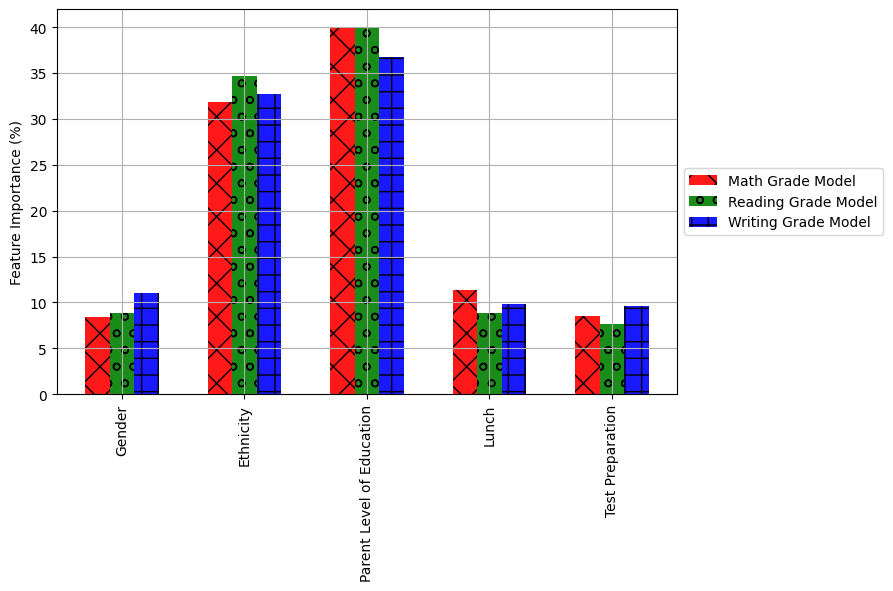

In [17]:
# ランダムフォレストにおける特徴量の重要度を確認

feature_names = ['Gender', 'Ethnicity', 'Parent Level of Education', 'Lunch', 'Test Preparation']
math_fi = math_model.feature_importances_ * 100
reading_fi = reading_model.feature_importances_ * 100
writing_fi = writing_model.feature_importances_ * 100

fig, ax = plt.subplots(figsize=(8, 5))
index = np.arange(len(feature_names))
bar_width = 0.2
opacity = 0.9
error_config = {'ecolor': '0.3'}
ax.bar(index, math_fi, bar_width, alpha=opacity, color='r', label='Math Grade Model', hatch='x')
ax.bar(index + bar_width, reading_fi, bar_width, alpha=opacity, color='g', label='Reading Grade Model', hatch='o')
ax.bar(index + bar_width * 2, writing_fi, bar_width, alpha=opacity, color='b', label='Writing Grade Model', hatch='+')
ax.set_xlabel('')
ax.set_ylabel('Feature Importance (%)')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(feature_names)
for tick in ax.get_xticklabels():
    tick.set_rotation(90)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True)

# いずれの科目でも親の学歴は重要そう

[0 1 2 3 4]
obtain pred_func from the provided model.


100%|██████████| 5/5 [00:00<00:00, 70.91it/s]


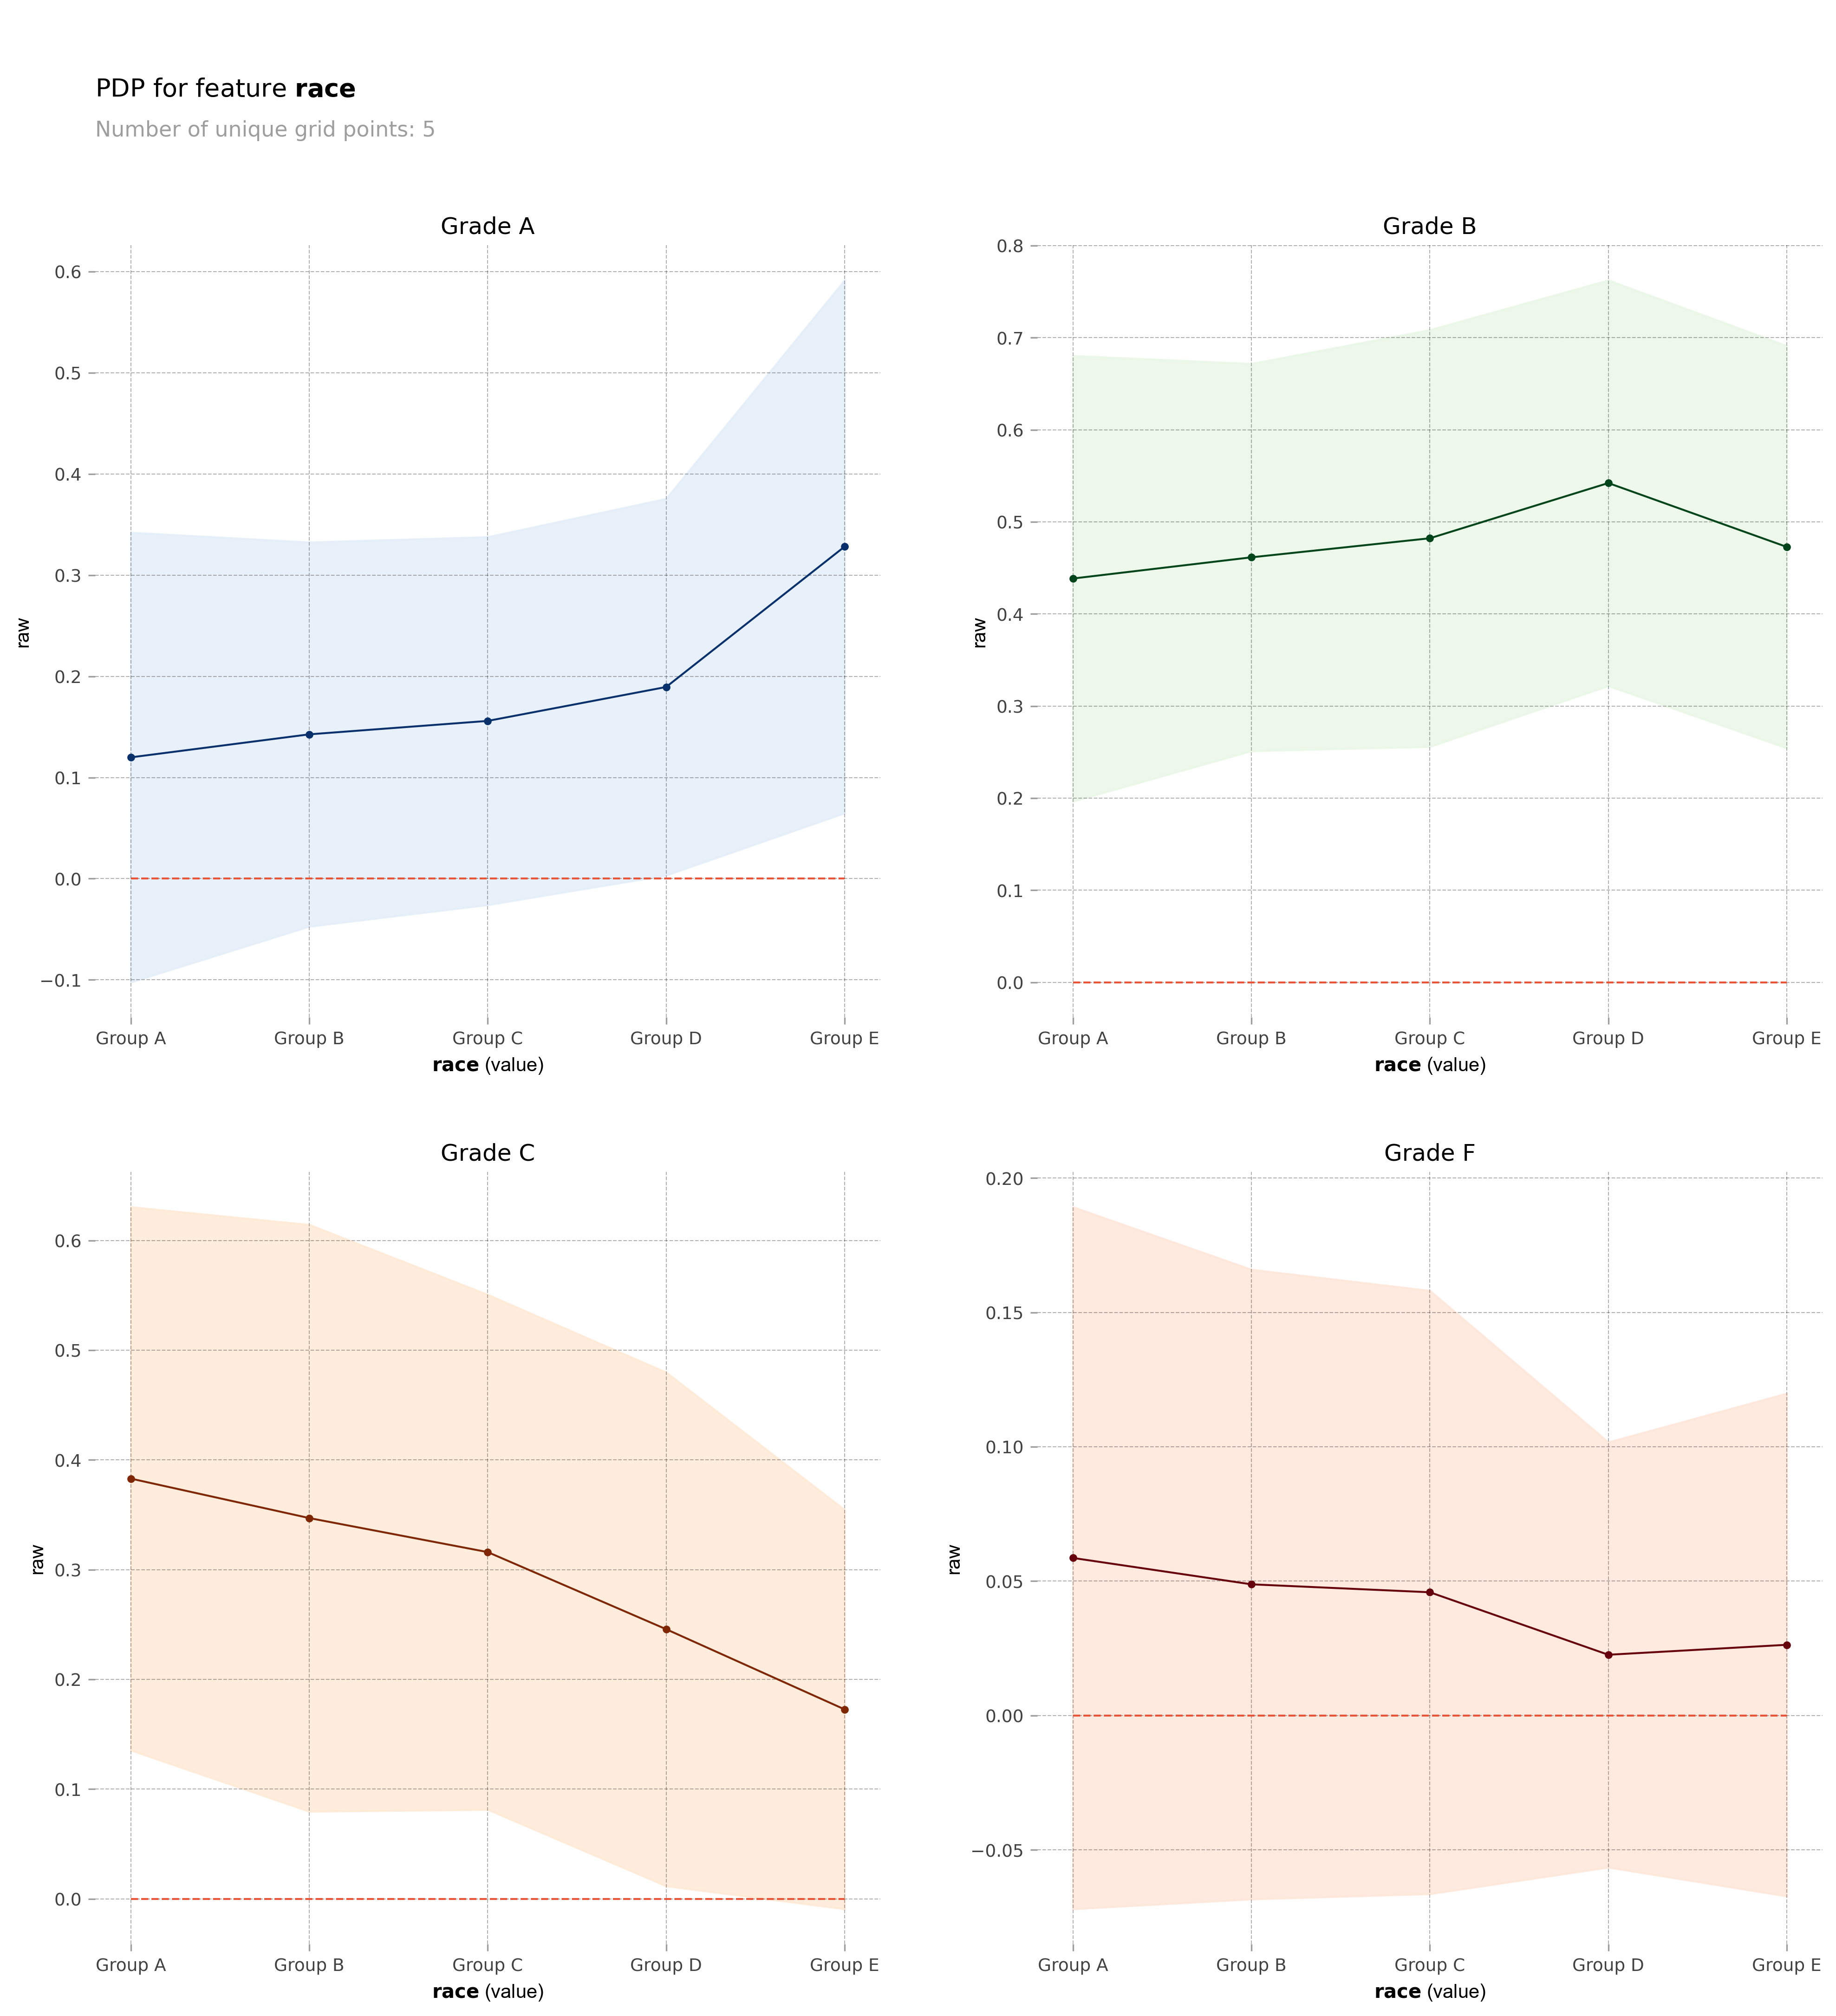

In [18]:
# 人種が数学の成績に及ぼす影響をPDPで確認

parent_codes = np.arange(0, 6)
parent_codes_decoded = [' '.join([x.capitalize() for x in p.split()]) for p in ple]
parent_title = str(dict(zip(parent_codes, parent_codes_decoded)))

race_codes = np.arange(0, 5)
race_codes_decoded = [' '.join([x.capitalize() for x in r.split()]) for r in race_le.inverse_transform(race_codes)]
race_title = str(dict(zip(race_codes, race_codes_decoded)))

print(race_codes)
parent_title = '{0: \'High School\', 1: \'Some High School\', 2: \'Some College\', 3: "Associate\'s Degree", 4: "Bachelor\'s Degree", 5: "Master\'s Degree"}'

pdp_race = pdp.PDPIsolate(model=math_model,
                          df=df,
                          model_features=feature_cols,
                          feature='race_le',
                          feature_name='race')
ethnicity_xtick_labels = ['Group A', 'Group B', 'Group C',
                          'Group D', 'Group E']
plot_params = {
    # plot title and subtitle
    'title': 'PDP for Ethnicity - Math Grade',
    'subtitle': 'Race/Ethnicity (Legend): \n%s' % (race_title),
    'title_fontsize': 15,
    'subtitle_fontsize': 12,
    # color for contour line
    'contour_color':  'white',
    'font_family': 'Arial',
    # matplotlib color map for interact plot
    'cmap': 'viridis',
    # fill alpha for interact plot
    'inter_fill_alpha': 0.8,
    # fontsize for interact plot text
    'inter_fontsize': 9,
}
fig, axes = pdp_race.plot(center=False, ncols=2, plot_lines=False, frac_to_plot=100, plot_params=plot_params, engine='matplotlib')

axes['line_axes'][0].set_title('Grade A')
axes['line_axes'][1].set_title('Grade B')
axes['line_axes'][2].set_title('Grade C')
axes['line_axes'][3].set_title('Grade F')

for i in range(len(axes['line_axes'])):
  axes['line_axes'][i].set_xticks(race_codes)
  axes['line_axes'][i].set_xticklabels(ethnicity_xtick_labels)

# Group Eが若干優秀に見える

obtain pred_func from the provided model.


100%|██████████| 6/6 [00:00<00:00, 69.77it/s]


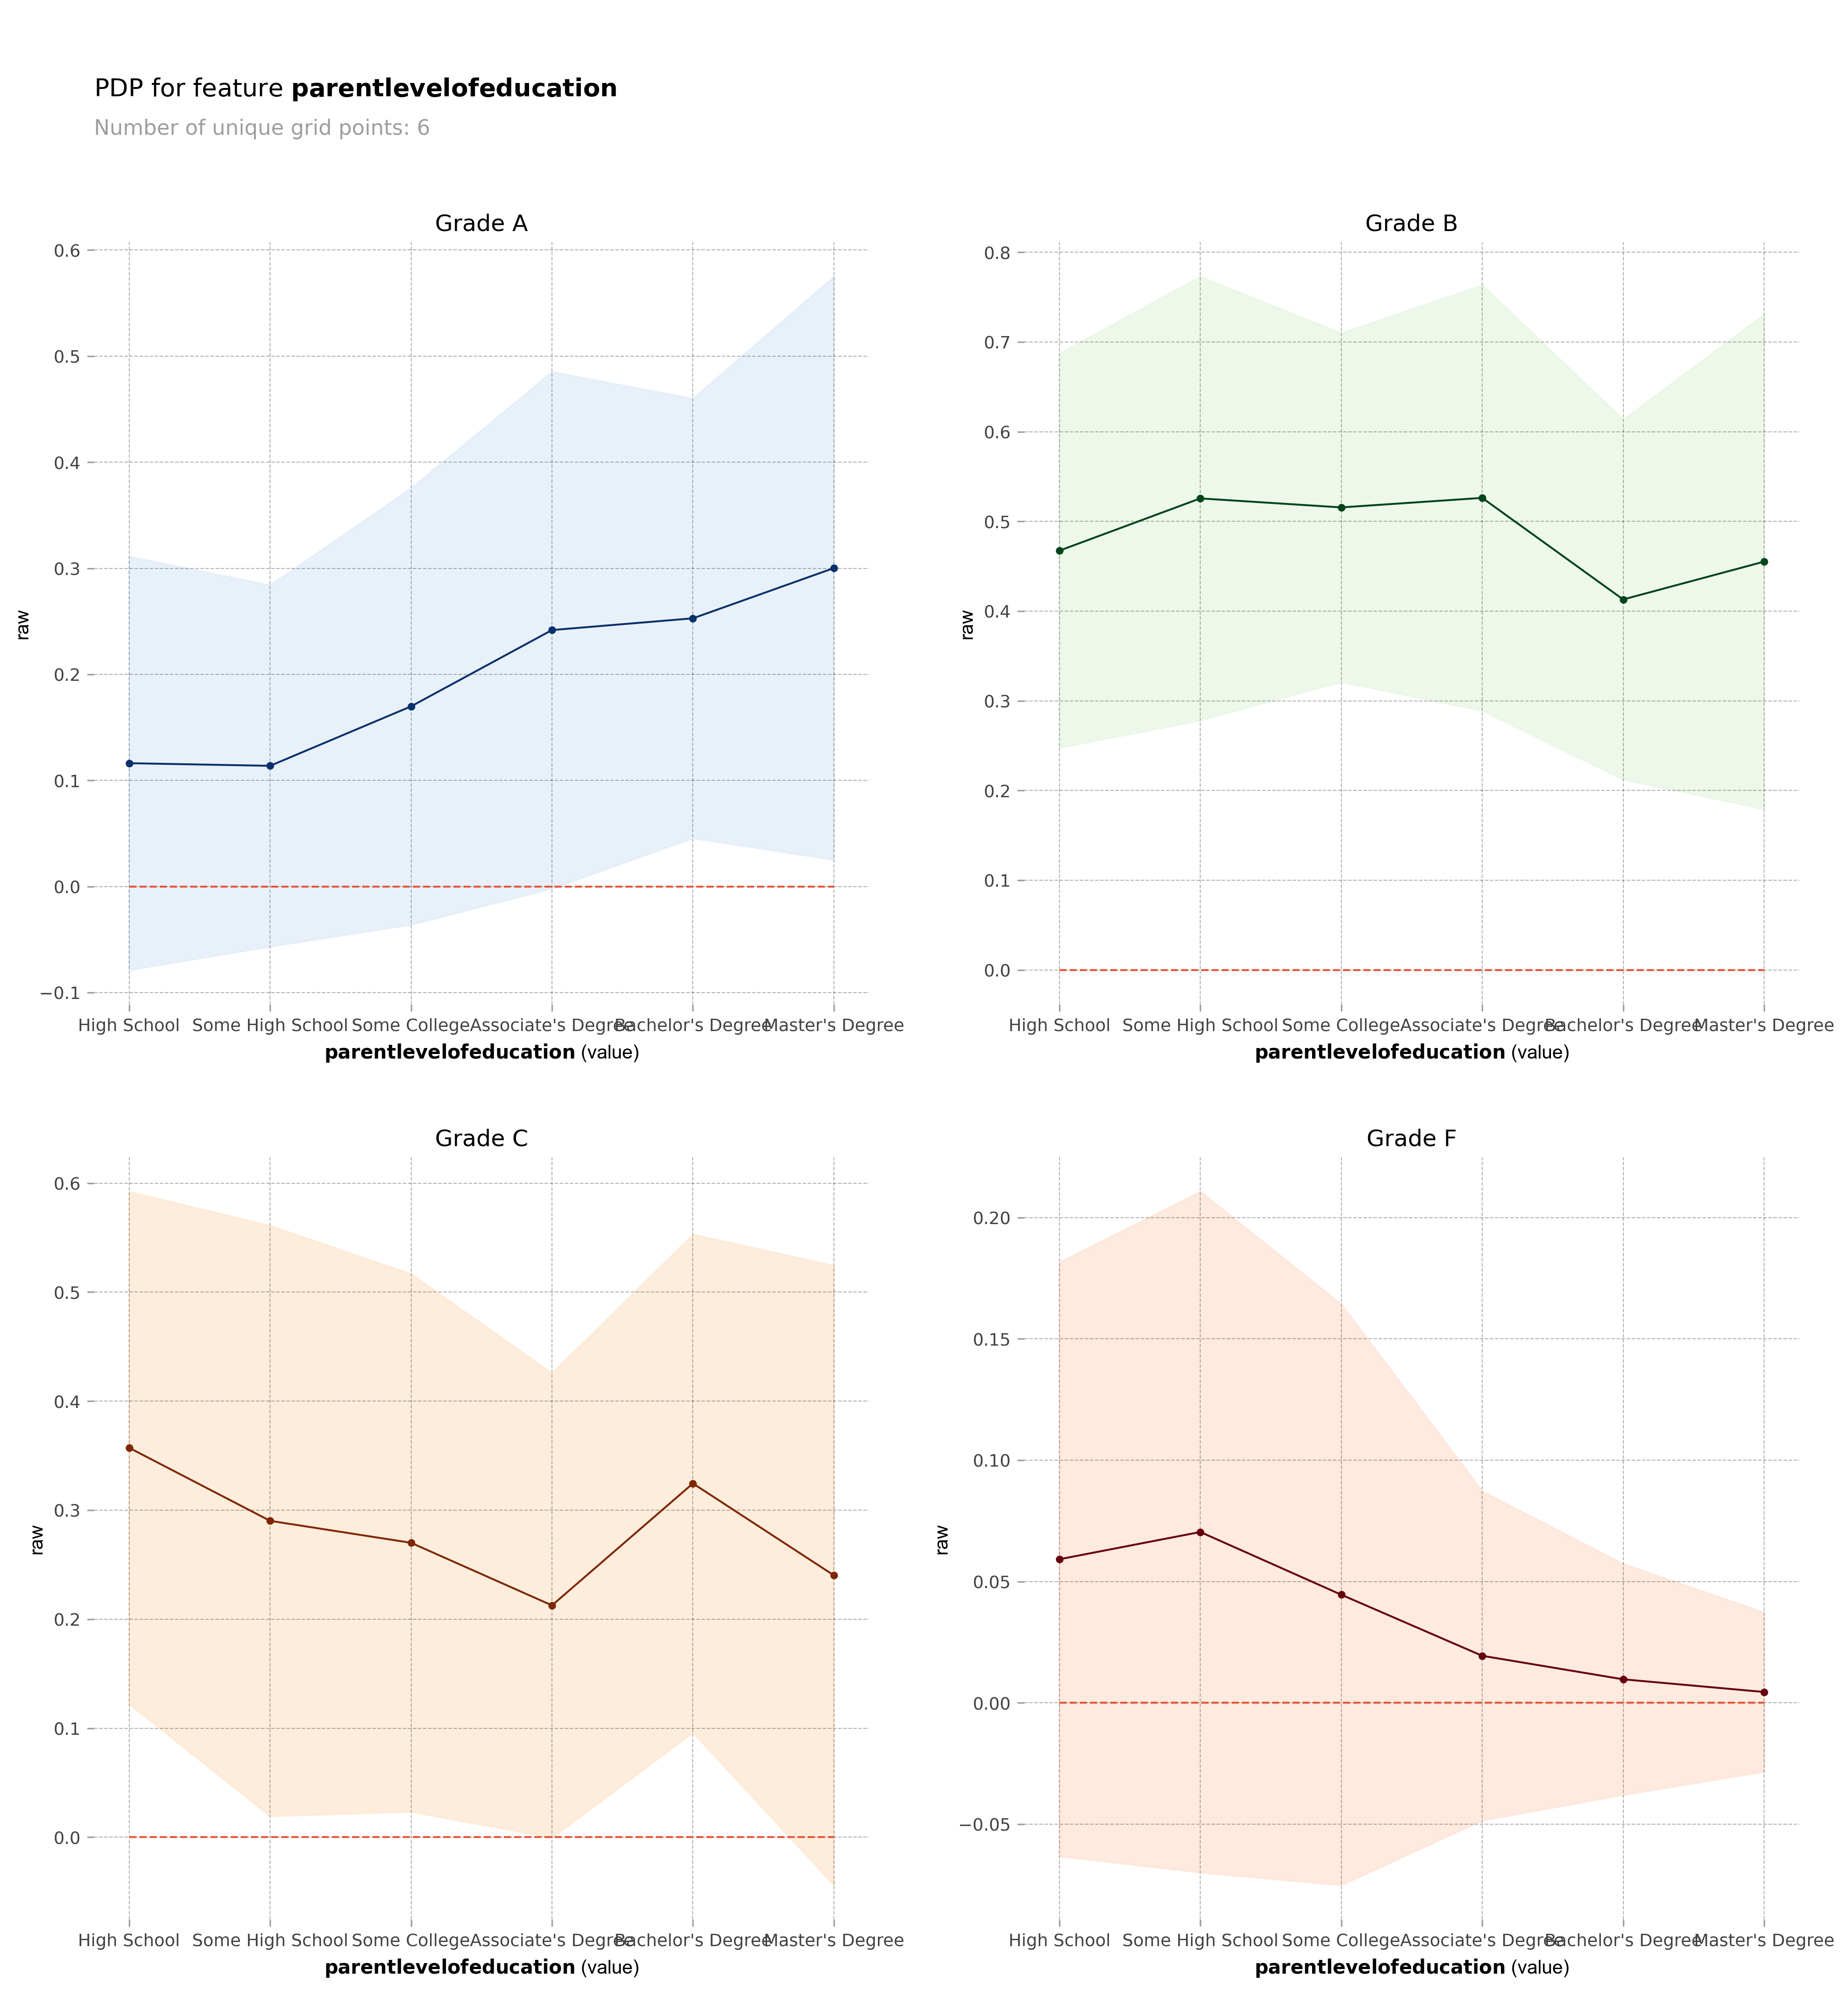

In [19]:
# 親の学歴はどうか

pdp_parent = pdp.PDPIsolate(model=math_model,
                          df=df,
                          model_features=feature_cols,
                          feature='parent_le',
                          feature_name='parent level of education')
ple_xticklabels = ['High School',
                   'Some High School',
                   'Some College',
                   "Associate\'s Degree",
                   "Bachelor\'s Degree",
                   "Master\'s Degree"]
plot_params = {
    # plot title and subtitle
    'title': 'PDP for Parent Level Educations - Math Grade',
    'subtitle': 'Parent Level Education (Legend): \n%s' % (parent_title),
    'title_fontsize': 15,
    'subtitle_fontsize': 12,
    # color for contour line
    'contour_color':  'white',
    'font_family': 'Arial',
    # matplotlib color map for interact plot
    'cmap': 'viridis',
    # fill alpha for interact plot
    'inter_fill_alpha': 0.8,
    # fontsize for interact plot text
    'inter_fontsize': 9,
}

fig, axes = pdp_parent.plot(center=False, ncols=2, plot_lines=False, frac_to_plot=100, plot_params=plot_params, engine='matplotlib')

axes['line_axes'][0].set_title('Grade A')
axes['line_axes'][1].set_title('Grade B')
axes['line_axes'][2].set_title('Grade C')
axes['line_axes'][3].set_title('Grade F')

for i in range(len(axes['line_axes'])):
  axes['line_axes'][i].set_xticks(parent_codes)
  axes['line_axes'][i].set_xticklabels(ple_xticklabels)

# Grade A/Fにおいて親がMaster持ちだと成績に顕著な影響が現れる

#### ICE

注目する説明変数を変更したときの目的変数の変化を確認

obtain pred_func from the provided model.


100%|██████████| 6/6 [00:00<00:00, 35.27it/s]


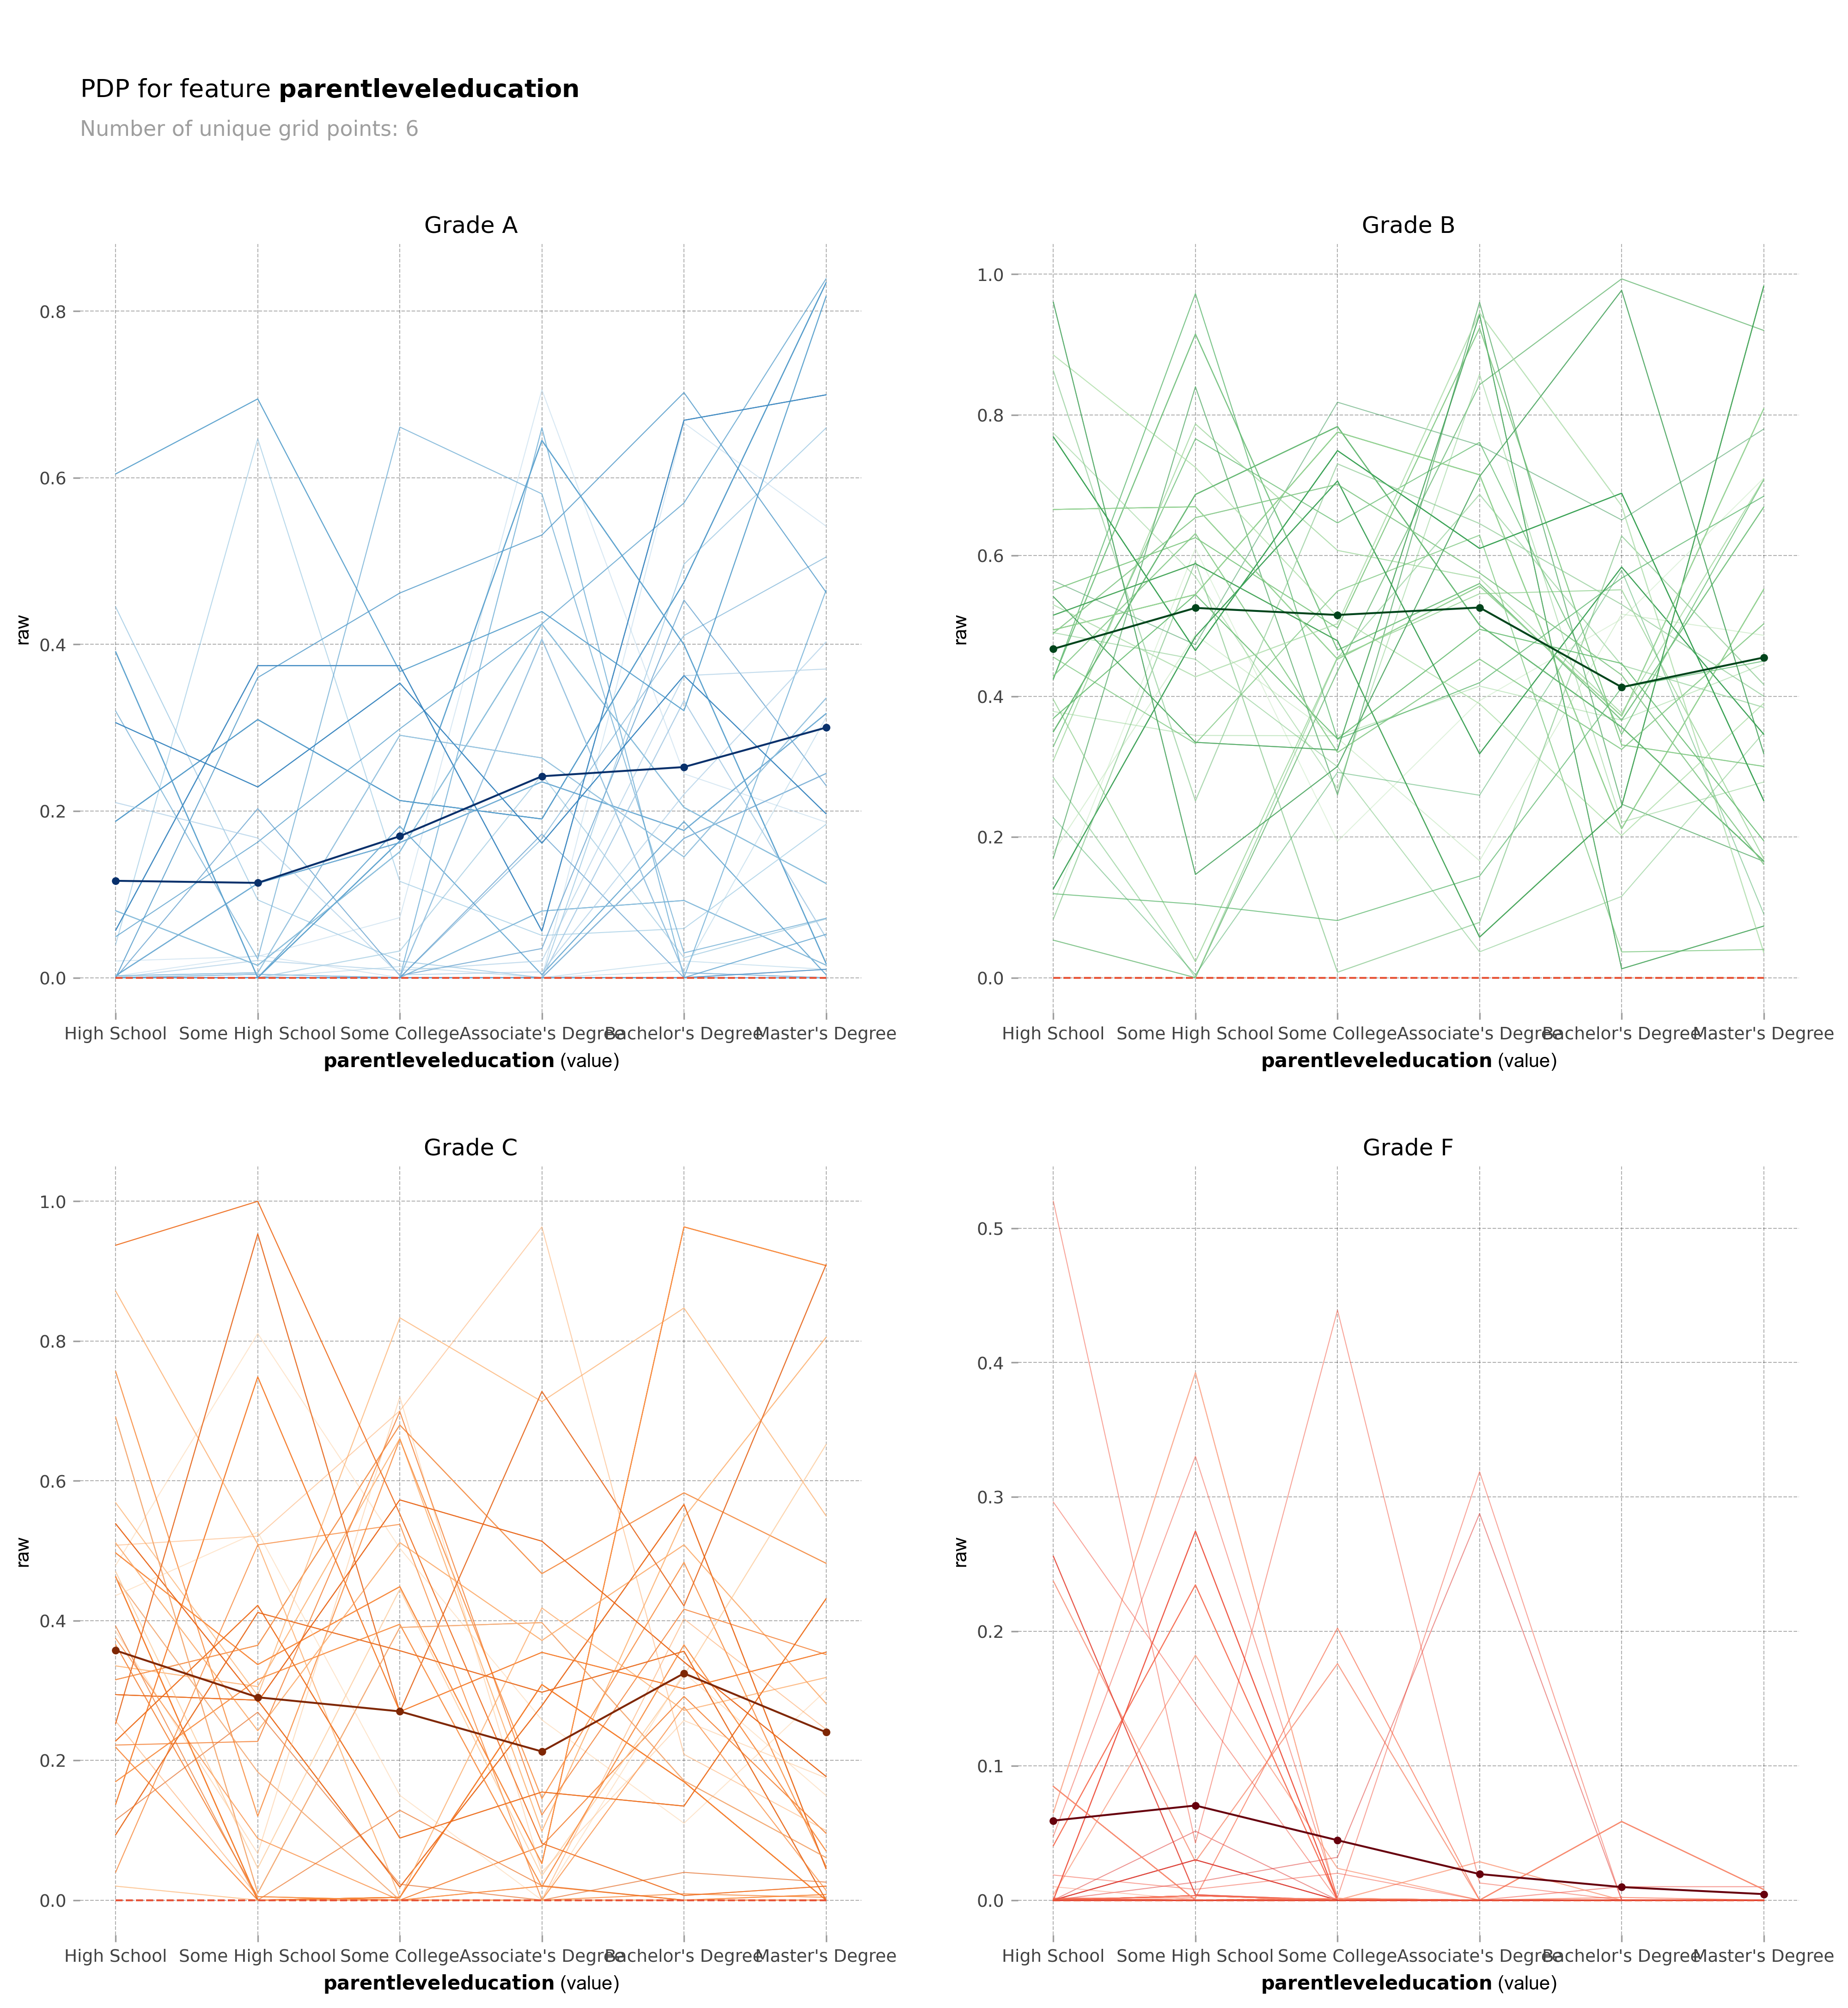

In [20]:
# 親の学歴を変更したときの成績の変化

pdp_race = pdp.PDPIsolate(model=math_model,
                          df=df,
                          model_features=feature_cols,
                          feature='parent_le',
                          feature_name='parent level education')

ple_xticklabels = ['High School', 'Some High School', 'Some College', "Associate\'s Degree", "Bachelor\'s Degree", "Master\'s Degree"]
plot_params = {
    # plot title and subtitle
    'title': 'ICE for Parent Level Educations - Math Grade',
    'subtitle': 'Parent Level Education (Legend): \n%s' % (parent_title),
    'title_fontsize': 15,
    'subtitle_fontsize': 12,
    # color for contour line
    'contour_color':  'white',
    'font_family': 'Arial',
    # matplotlib color map for interact plot
    'cmap': 'viridis',
    # fill alpha for interact plot
    'inter_fill_alpha': 0.8,
    # fontsize for interact plot text
    'inter_fontsize': 9,
}

fig, axes = pdp_race.plot(center=False, ncols=2, plot_lines=True, frac_to_plot=100, plot_params=plot_params, engine='matplotlib')

axes['line_axes'][0].set_title('Grade A')
axes['line_axes'][1].set_title('Grade B')
axes['line_axes'][2].set_title('Grade C')
axes['line_axes'][3].set_title('Grade F')

for i in range(len(axes['line_axes'])):
  axes['line_axes'][i].set_xticks(parent_codes)
  axes['line_axes'][i].set_xticklabels(ple_xticklabels)

#### 特徴量の相互作用

特徴量のペアを変更して目的変数がどう変わるかを確認

obtain pred_func from the provided model.


100%|██████████| 5/5 [00:00<00:00, 64.14it/s]


obtain pred_func from the provided model.


100%|██████████| 6/6 [00:00<00:00, 72.05it/s]


obtain pred_func from the provided model.


100%|██████████| 30/30 [00:00<00:00, 69.75it/s]


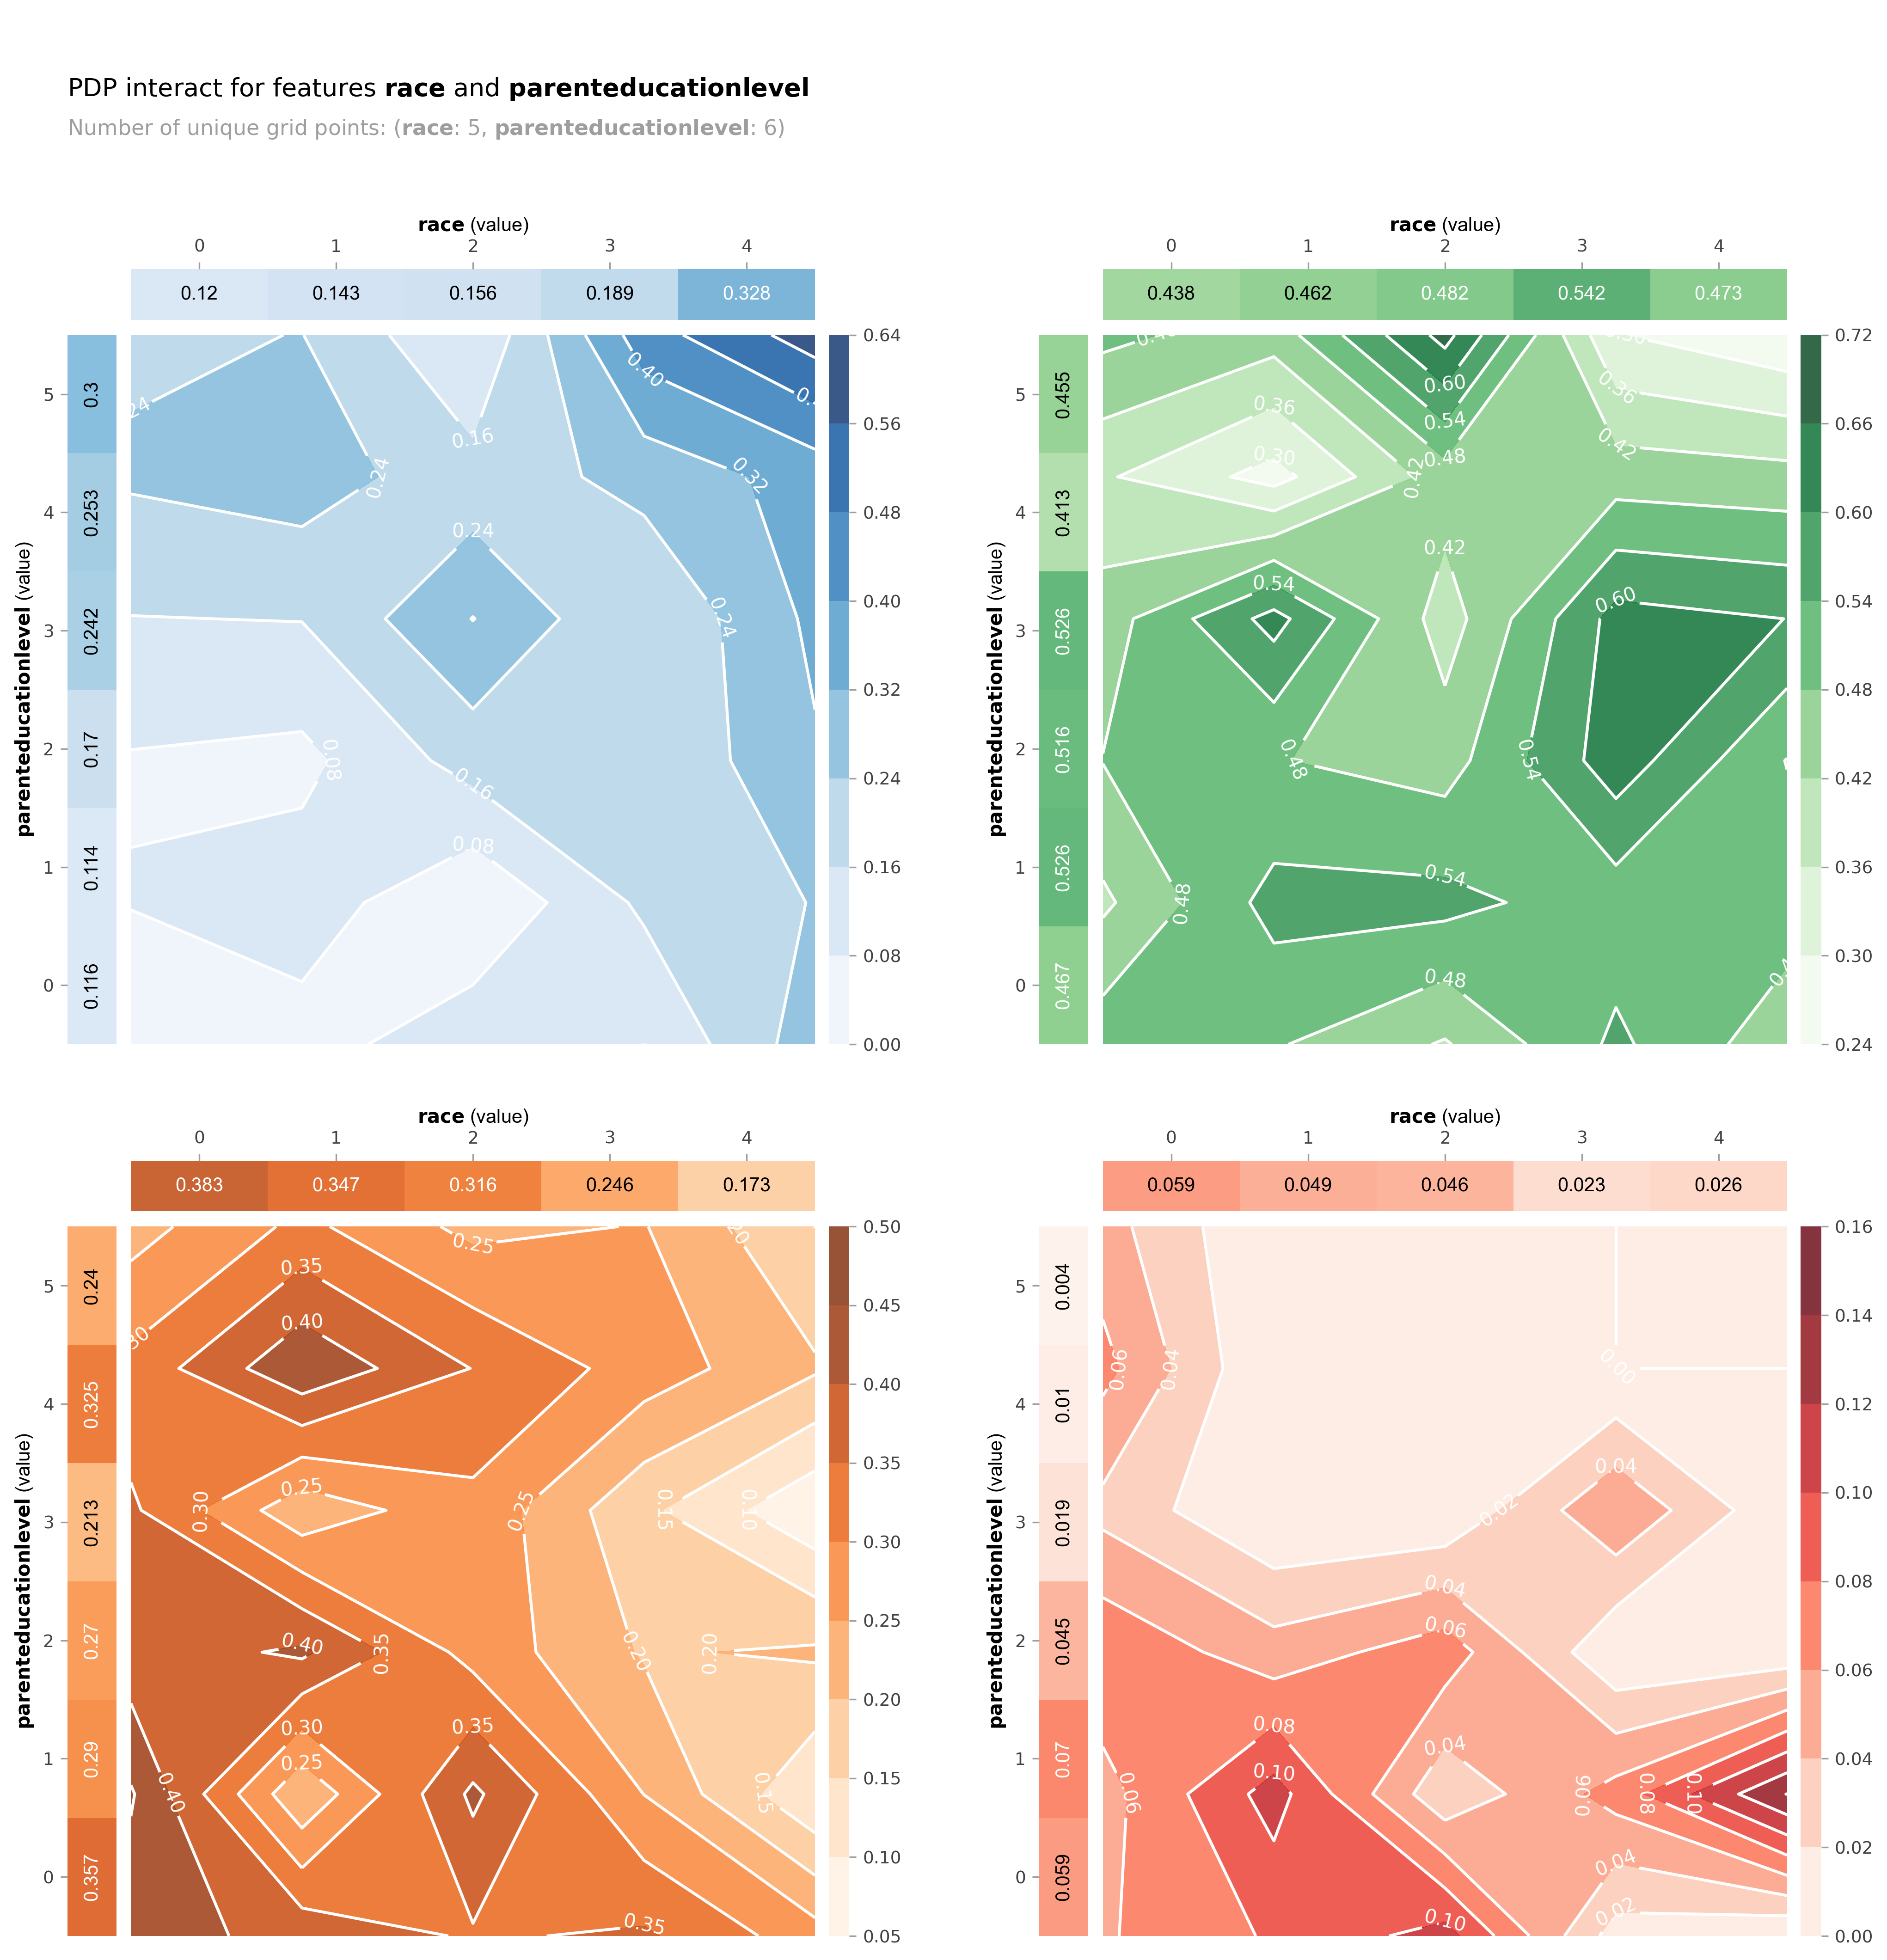

In [21]:
pdp_race_parent = pdp.PDPInteract(model=math_model,
                                   df=df,
                                   model_features=feature_cols,
                                   features=['race_le', 'parent_le'],
                                   feature_names=['race', 'parent education level'])

plot_params = {
    # plot title and subtitle
    'title': 'PDP Interaction - Math Grade',
    'subtitle': 'Race/Ethnicity (Legend): \n%s\nParent Level of Education (Legend): \n%s' % (race_title, parent_title),
    'title_fontsize': 15,
    'subtitle_fontsize': 12,
    # color for contour line
    'contour_color':  'white',
    # 'font_family': 'Arial',
    # matplotlib color map for interact plot
    'cmap': 'viridis',
    # fill alpha for interact plot
    'inter_fill_alpha': 0.8,
    # fontsize for interact plot text
    'inter_fontsize': 9,
}
fig, axes = pdp_race_parent.plot(plot_type='contour', plot_pdp=True, plot_params=plot_params, engine='matplotlib')

# 本当はplot_type='grid'で実行したかった

### 局所的な解釈可能性

#### 乳がんデータの読み込み

In [22]:
# データの読み込み

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import torch
torch.manual_seed(24)
from torch.autograd import Variable

data = load_breast_cancer()

X = data['data']
y = data['target']

# 訓練/検証/テストデータに分割

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=24)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=24)
X_train = Variable(torch.from_numpy(X_train))
X_val = Variable(torch.from_numpy(X_val))
y_train = Variable(torch.from_numpy(y_train))
y_val = Variable(torch.from_numpy(y_val))
X_test = Variable(torch.from_numpy(X_test))
y_test = Variable(torch.from_numpy(y_test))

print(X.shape)

ModuleNotFoundError: No module named 'torch'

In [ ]:
# ターゲットは良性/悪性

import pandas as pd

df_data = pd.DataFrame(X, columns=data['feature_names'])
df_data['target'] = y
df_benign = df_data[df_data['target']==1].reset_index(drop=True)
df_malignant = df_data[df_data['target']==0].reset_index(drop=True)
df_train = pd.DataFrame(X_train, columns=data['feature_names'])
df_train['target'] = y_train
df_val = pd.DataFrame(X_val, columns=data['feature_names'])
df_val['target'] = y_val
df_test = pd.DataFrame(X_test, columns=data['feature_names'])
df_test['target'] = y_test
df_data.head()

#### EDA

In [ ]:
# 良性/悪性の割合

df_data['target'].value_counts() / len(df_data) * 100

# 1が良性/0が悪性

In [ ]:
# ↑を可視化

import matplotlib.pyplot as plt
import seaborn as sns

class_names = ['Benign', 'Malignant']
class_pc = [62.8, 37.3]
f, ax = plt.subplots()
sns.barplot(x=class_names, y=class_pc, ax=ax)
ax.set_ylabel('% of Cases')

In [ ]:
# 訓練/検証/テストデータにおける良性/悪性の分布

f, ax = plt.subplots(1, 3, figsize=(20, 5))
df_train['target'].value_counts(normalize=True).rename('pc').reset_index().rename(columns={'index': 'target'}).pipe((sns.barplot, "data"), x='target', y='pc', ax=ax[0])
df_val['target'].value_counts(normalize=True).rename('pc').reset_index().rename(columns={'index': 'target'}).pipe((sns.barplot, "data"), x='target', y='pc', ax=ax[1])
df_test['target'].value_counts(normalize=True).rename('pc').reset_index().rename(columns={'index': 'target'}).pipe((sns.barplot, "data"), x='target', y='pc', ax=ax[2])
ax[0].set_ylabel('Proportion of patches')
ax[1].set_ylabel('Proportion of patches')
ax[2].set_ylabel('Proportion of patches')
ax[0].set_ylim([0, 0.8])
ax[1].set_ylim([0, 0.8])
ax[2].set_ylim([0, 0.8])
ax[0].set_title('Training Set')
ax[1].set_title('Validation Set')
ax[2].set_title('Test Set')

In [ ]:
# 細胞の面積(平均/最悪)と良性/悪性

f, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.distplot(df_benign['mean area'], bins=5, ax=ax[0], label='Benign', hist_kws={"hatch": "x"})
sns.distplot(df_malignant['mean area'], bins=20, ax=ax[0], label='Malignant')
ax[0].legend()
sns.distplot(df_benign['worst area'], bins=5, ax=ax[1], label='Benign', hist_kws={"hatch": "x"})
sns.distplot(df_malignant['worst area'], bins=20, ax=ax[1], label='Malignant')
ax[1].legend()
ax[0].set_title('Mean Cell Area Distribution')
ax[1].set_title('Worst Cell Area Distribution')

In [ ]:
# 細胞の半径(平均/最悪)と良性/悪性

f, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.distplot(df_benign['mean radius'], bins=5, ax=ax[0], label='Benign', hist_kws={"hatch": "x"})
sns.distplot(df_malignant['mean radius'], bins=20, ax=ax[0], label='Malignant')
sns.distplot(df_benign['worst radius'], bins=5, ax=ax[1], label='Benign', hist_kws={"hatch": "x"})
sns.distplot(df_malignant['worst radius'], bins=20, ax=ax[1], label='Malignant')
ax[0].legend()
ax[1].legend()
ax[0].set_title('Mean Cell Radius Distribution')
ax[1].set_title('Worst Cell Radius Distribution')

In [ ]:
# 細胞の周囲長(平均/最悪)と良性/悪性

f, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.distplot(df_benign['mean perimeter'], bins=5, ax=ax[0], label='Benign', hist_kws={"hatch": "x"})
sns.distplot(df_malignant['mean perimeter'], bins=20, ax=ax[0], label='Malignant')
sns.distplot(df_benign['worst perimeter'], bins=5, ax=ax[1], label='Benign', hist_kws={"hatch": "x"})
sns.distplot(df_malignant['worst perimeter'], bins=20, ax=ax[1], label='Malignant')
ax[0].legend()
ax[1].legend()
ax[0].set_title('Mean Cell Perimeter Distribution')
ax[1].set_title('Worst Cell Perimeter Distribution')

In [ ]:
# 説明変数と目的変数のヒートマップ

corr = df_data.corr()

f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap="PiYG", square=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')

# 一番下の行の色が濃いところがポイントとなる説明変数

#### ニューラルネットワークによる予測モデルの作成

In [ ]:
# ネットワークの構築

class Model(torch.nn.Sequential):
    def __init__(self, layer_dims):
        super(Model, self).__init__()
        for idx, dim in enumerate(layer_dims):
            if (idx < len(layer_dims) - 1):
                module = torch.nn.Linear(dim, layer_dims[idx + 1])
                self.add_module("linear" + str(idx), module)
            else:
                self.add_module("sig" + str(idx), torch.nn.Sigmoid())
            if (idx < len(layer_dims) - 2):
                self.add_module("relu" + str(idx), torch.nn.ReLU())

dim_in = X_train.shape[1]
dim_out = 1
layer_dims = [dim_in, 20, 10, 5, dim_out]
model = Model(layer_dims)
print(model)

In [ ]:
# 訓練開始

criterion = torch.nn.BCELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 300
history = { "loss": [], "accuracy": [], "loss_val": [], "accuracy_val": [] }
for epoch in range(num_epochs):
    y_pred = model(X_train.float())
    loss = criterion(y_pred, y_train.view(-1, 1).float())
    prediction = [1 if p > 0.5 else 0 for p in y_pred.data.numpy()]
    correct = (prediction == y_train.numpy()).mean()

    y_pred_val = model(X_val.float())
    loss_val = criterion(y_pred_val, y_val.view(-1,1).float())
    prediction_val = [1 if p > 0.5 else 0 for p in y_pred_val.data.numpy()]
    correct_val = (prediction_val == y_val.numpy()).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print('Epoch', epoch, 'Loss:', loss.item(), '- Pred:', y_pred.data[0])
    history["loss"].append(loss.item())
    history["accuracy"].append(100 * correct)
    history["loss_val"].append(loss_val.data.item())
    history["accuracy_val"].append(100 * correct_val)

In [ ]:
# 予測モデルの評価
# 比較対象(ベースライン)=常に"良性"と予測

import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

y_pred_test = model.forward(X_test.float()) > 0.5
y_conf = model.forward(X_test.float()).detach().numpy().reshape(-1)
pred = y_pred_test.numpy().reshape(-1)
actual = y_test.numpy()
baseline = np.array([1 for _ in range(len(actual))])

precision = precision_score(actual, pred)
p_baseline = precision_score(actual, baseline)
r_baseline = recall_score(actual, baseline)
recall = recall_score(actual, pred)
f1 = f1_score(actual, pred)
f1_baseline = f1_score(actual, baseline)
print('Precision: ', precision, 'Recall: ', recall, 'F1: ', f1)
print('(Baseline) Precision: ', p_baseline, 'Recall: ', r_baseline, 'F1: ', f1_baseline)

In [ ]:
# PR曲線

from sklearn.metrics import average_precision_score, precision_recall_curve

pred_p, pred_r, _ = precision_recall_curve(actual, y_conf)
baseline_p, baseline_r, _ = precision_recall_curve(actual, baseline)
pred_ap = average_precision_score(actual, pred)
baseline_ap = average_precision_score(actual, baseline)
f, ax = plt.subplots(figsize=(8, 5))
ax.plot(pred_r, pred_p, label='DNN (Average Precision: %d%%)' % round(pred_ap * 100))
ax.plot(baseline_r, baseline_p, label='Baseline (Average Precision: %d%%)' % round(baseline_ap * 100))
ax.legend()
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')

In [ ]:
# ASCII的な表を作るためのライブラリ

!pip install prettytable

In [ ]:
# モデルの複雑さ

from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad: continue
        param = parameter.numel()
        table.add_row([name, param])
        total_params += param
    print(table)
    print(f"Total Trainable Parameters: {total_params}")
    return total_params

count_parameters(model)

### LIME (Local Interpretable Model-agnostic Explanations)

Ribeiro et al.が2016年に提案

1. サンプルを1つ選択

2. 各特徴量をサンプリングして新たなデータを作成

3. サンプルしたデータを予測モデルに与えて出力を確認

4. 1.で選んだデータと3.のデータとの距離を計算して近いサンプルデータに大きく重み付け

5. 大きい重み付けがされたデータを予測するホワイトボックスモデルを構築

In [ ]:
# LIMEのライブラリのインストール

!pip install lime

In [ ]:
# LIMEを使って良性のサンプルを解釈

from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X_train.numpy(), feature_names=data.feature_names, class_names=data.target_names, discretize_continuous=True)

benign_idx = np.where(y_test.numpy() == 1)[0][0]
malignant_idx = np.where(y_test.numpy() == 0)[0][0]

def lime_exp_as_pyplot(exp, label=0, figsize=(8, 5)):
    exp_list = exp.as_list(label=label)
    fig, ax = plt.subplots(figsize=figsize)
    vals = [x[1] for x in exp_list]
    names = [x[0] for x in exp_list]
    vals.reverse()
    names.reverse()
    colors = ['green' if x > 0 else 'red' for x in vals]
    pos = np.arange(len(exp_list)) + .5
    ax.barh(pos, vals, align='center', color=colors)
    plt.yticks(pos, names)
    return fig, ax

def prob(data):
    return model.forward(Variable(torch.from_numpy(data)).float()).detach().numpy().reshape(-1, 1)

bc1_lime = explainer.explain_instance(X_test.numpy()[benign_idx], prob, num_features=5, top_labels=1)
f, ax = lime_exp_as_pyplot(bc1_lime)
ax.set_title('Benign Case 1 (DNN Confidence: %d%%) | Kernel Width = None (Score: %.2f)' % (round(y_conf[benign_idx] * 100), bc1_lime.score))

# デフォルトだとkernel width = sqrt(#features) * 0.75

In [ ]:
# 悪性の方もチャレンジ

exp = explainer.explain_instance(X_test.numpy()[malignant_idx], prob, num_features=5, top_labels=1)
f, ax = lime_exp_as_pyplot(exp)
ax.set_title('Malignant Case 1 (DNN Confidence: %d%%) | Kernel Width = None (Score: %.2f)' % (100 - round(y_conf[malignant_idx] * 100), exp.score))

In [ ]:
# 良性のサンプルを変更

benign_idx2 = np.where(y_test.numpy()==1)[0][1]
exp = explainer.explain_instance(X_test.numpy()[benign_idx2], prob, num_features=5, top_labels=1)
f, ax = lime_exp_as_pyplot(exp)
ax.set_title('Benign Case 2 (DNN Confidence: %d%%) | Kernel Width = None (Score: %.2f)' % (round(y_conf[benign_idx2] * 100), exp.score))

In [ ]:
# 悪性のサンプルも変えてみる

malignant_idx2 = np.where(y_test.numpy()==0)[0][1]
exp = explainer.explain_instance(X_test.numpy()[malignant_idx2], prob, num_features=5, top_labels=1)
f, ax = lime_exp_as_pyplot(exp)
ax.set_title('Malignant Case 2 (DNN Confidence: %d%%) | Kernel Width = None (Score: %.2f)' % (100 - round(y_conf[malignant_idx2] * 100), exp.score))

In [ ]:
# カーネルの幅を1に広げてみる
# サンプルを良性の1番目

explainer_kw1 = LimeTabularExplainer(X_train.numpy(), feature_names=data.feature_names, class_names=data.target_names, kernel_width=1, discretize_continuous=True)
exp = explainer_kw1.explain_instance(X_test.numpy()[benign_idx], prob, num_features=5, top_labels=1)
f, ax = lime_exp_as_pyplot(exp)
ax.set_title('DNN Confidence that Case is Benign: %d%%' % (round(y_conf[benign_idx] * 100)))

In [ ]:
# サンプルを良性2に変更

exp = explainer_kw1.explain_instance(X_test.numpy()[benign_idx2], prob, num_features=5, top_labels=1)
f, ax = lime_exp_as_pyplot(exp)
ax.set_title('Benign Case 2 (DNN Confidence: %d%%) | Kernel Width = 1 (Score: %.2f)' % (round(y_conf[benign_idx2] * 100), exp.score))

In [ ]:
# 悪性No.2でもやってみる

malignant_idx2 = np.where(y_test.numpy()==0)[0][1]
exp = explainer_kw1.explain_instance(X_test.numpy()[malignant_idx2], prob, num_features=5, top_labels=1)
f, ax = lime_exp_as_pyplot(exp)
ax.set_title('Malignant Case 2 (DNN Confidence: %d%%) | Kernel Width = 1 (Score: %.2f)' % (100 - round(y_conf[malignant_idx2] * 100), exp.score))

### SHAP (SHapley Additive exPlanations)

LIMEにゲーム理論を融合

摂動データセットの作り方に工夫

特徴量のうち選ばれたものは実際の値を採用

選ばれなかった特徴量についてはランダムサンプリング

In [ ]:
!pip uninstall -y shap
!pip install git+https://github.com/thampiman/shap

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.23.5

In [ ]:
# 良性のケースでのSHAP valueを表示

import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import torch
torch.manual_seed(24)
from torch.autograd import Variable
import torch.utils.data as data_utils
import torch.nn.init as init
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

class Model(torch.nn.Sequential):
    def __init__(self, layer_dims):
        super(Model, self).__init__()
        for idx, dim in enumerate(layer_dims):
            if (idx < len(layer_dims) - 1):
                module = torch.nn.Linear(dim, layer_dims[idx + 1])
                self.add_module("linear" + str(idx), module)
            else:
                self.add_module("sig" + str(idx), torch.nn.Sigmoid())
            if (idx < len(layer_dims) - 2):
                self.add_module("relu" + str(idx), torch.nn.ReLU())

shap.initjs()

data = load_breast_cancer()
X = data['data']
y = data['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=24)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=24)
X_train = Variable(torch.from_numpy(X_train))
X_val = Variable(torch.from_numpy(X_val))
y_train = Variable(torch.from_numpy(y_train))
y_val = Variable(torch.from_numpy(y_val))
X_test = Variable(torch.from_numpy(X_test))
y_test = Variable(torch.from_numpy(y_test))

dim_in = X_train.shape[1]
dim_out = 1
layer_dims = [dim_in, 20, 10, 5, dim_out]
model = Model(layer_dims)

def prob(data):
    return model.forward(Variable(torch.from_numpy(data)).float()).detach().numpy().reshape(-1, 1)

shap_explainer = shap.KernelExplainer(prob, X_train.numpy(), link="logit")
shap_values = shap_explainer.shap_values(X_test.numpy(), nsamples=100)

benign_idx = np.where(y_test.numpy()==1)[0][0]
malignant_idx = np.where(y_test.numpy()==0)[0][0]
benign_idx2 = np.where(y_test.numpy()==1)[0][1]
malignant_idx2 = np.where(y_test.numpy()==0)[0][1]

df_test = pd.DataFrame(X_test.numpy(), columns=data['feature_names'])

plot = shap.force_plot(shap_explainer.expected_value,
                       shap_values[0][benign_idx, :],
                       X_test.numpy()[benign_idx, :],
                       feature_names=data['feature_names'],
                       link="logit")
plot

In [ ]:
# 別の良性のデータでチャレンジ

shap.initjs()

plot = shap.force_plot(shap_explainer.expected_value[0],
                        shap_values[0][benign_idx2,:],
                        X_test.numpy()[benign_idx2,:],
                        feature_names=data['feature_names'],
                        link="logit")
plot

In [ ]:
# 悪性の方は?

shap.initjs()

plot = shap.force_plot(shap_explainer.expected_value[0],
                       shap_values[0][malignant_idx,:],
                       X_test.numpy()[malignant_idx,:],
                       feature_names=data['feature_names'],
                       link="logit")
plot

In [ ]:
# 悪性のもう1つのサンプル

shap.initjs()

plot = shap.force_plot(shap_explainer.expected_value[0],
                       shap_values[0][malignant_idx2,:],
                       X_test.numpy()[malignant_idx2,:],
                       feature_names=data['feature_names'],
                       link="logit")
plot

### アンカー

LIMEの制作者が2018年に提案

アンカー=解釈したいインスタンスを含むif条件の集合

その後各アンカーの範囲をカバー率で定量化

In [ ]:
!pip install anchor-exp

In [ ]:
# 良性サンプル1の解釈

from anchor import utils, anchor_tabular

anchor_explainer = anchor_tabular.AnchorTabularExplainer(data.target_names, data.feature_names, X_train.numpy(), categorical_names={})

def pred(data):
    pred = model.forward(Variable(torch.from_numpy(data)).float()).detach().numpy().reshape(-1) > 0.5
    return np.array([1 if p == True else 0 for p in pred])

benign_idx = np.where(y_test.numpy() == 1)[0][0]
malignant_idx = np.where(y_test.numpy() == 0)[0][0]
benign_idx2 = np.where(y_test.numpy() == 1)[0][1]
malignant_idx2 = np.where(y_test.numpy() == 0)[0][1]

exp = anchor_explainer.explain_instance(X_test.numpy()[benign_idx], pred, threshold=0.95)
print('Prediction: ', anchor_explainer.class_names[pred(X_test.numpy()[benign_idx])][0])
print('Anchor: %s' % (' AND '.join(exp.names())))
print('Precision: %.3f' % exp.precision())
print('Coverage: %.3f' % exp.coverage())

In [ ]:
# 良性サンプル2の解釈

print('Prediction: ', anchor_explainer.class_names[pred(X_test.numpy()[benign_idx2])][0])
exp = anchor_explainer.explain_instance(X_test.numpy()[benign_idx2], pred, threshold=0.95)
print('Anchor: %s' % (' AND '.join(exp.names())))
print('Precision: %.3f' % exp.precision())
print('Coverage: %.3f' % exp.coverage())

In [ ]:
# 悪性サンプル1の解釈

print('Prediction: ', anchor_explainer.class_names[pred(X_test.numpy()[malignant_idx])][0])
exp = anchor_explainer.explain_instance(X_test.numpy()[malignant_idx], pred, threshold=0.95)
print('Anchor: %s' % (' AND '.join(exp.names())))
print('Precision: %.3f' % exp.precision())
print('Coverage: %.3f' % exp.coverage())

In [ ]:
# 悪性サンプル2の解釈

print('Prediction: ', anchor_explainer.class_names[pred(X_test.numpy()[malignant_idx2])][0])
exp = anchor_explainer.explain_instance(X_test.numpy()[malignant_idx2], pred, threshold=0.95)
print('Anchor: %s' % (' AND '.join(exp.names())))
print('Precision: %.3f' % exp.precision())
print('Coverage: %.3f' % exp.coverage())

Google Colaboratoryで実行すると結果が謎